In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
trade_files = [
    "data/raw/by_country/Argentina_trade_2014_2025.csv",
    "data/raw/by_country/Australia_trade_2014_2025.csv",
    "data/raw/by_country/Brazil_trade_2014_2025.csv",
    "data/raw/by_country/Canada_trade_2014_2025.csv",
    "data/raw/by_country/China_trade_2014_2025.csv",
    "data/raw/by_country/France_trade_2014_2025.csv",
    "data/raw/by_country/Germany_trade_2014_2025.csv",
    "data/raw/by_country/India_trade_2014_2025.csv",
    "data/raw/by_country/Indonesia_trade_2014_2025.csv",
    "data/raw/by_country/Italy_trade_2014_2025.csv",
    "data/raw/by_country/Japan_trade_2014_2025.csv",
    "data/raw/by_country/Mexico_trade_2014_2025.csv",
    "data/raw/by_country/Republic_of_Korea_trade_2014_2025.csv",
    "data/raw/by_country_second_key/Saudi_Arabia_trade_201401_202512.csv",
    "data/raw/by_country_second_key/South_Africa_trade_201401_202512.csv",
    "data/raw/by_country_second_key/Turkiye_trade_201401_202512.csv",
    "data/raw/by_country_second_key/United_Kingdom_trade_201401_202512.csv",
    "data/raw/by_country_second_key/United_States_trade_201401_202512.csv",
]

print("Number of selected trade files:", len(trade_files))

for file in trade_files:
    print(file)

Number of selected trade files: 18
data/raw/by_country/Argentina_trade_2014_2025.csv
data/raw/by_country/Australia_trade_2014_2025.csv
data/raw/by_country/Brazil_trade_2014_2025.csv
data/raw/by_country/Canada_trade_2014_2025.csv
data/raw/by_country/China_trade_2014_2025.csv
data/raw/by_country/France_trade_2014_2025.csv
data/raw/by_country/Germany_trade_2014_2025.csv
data/raw/by_country/India_trade_2014_2025.csv
data/raw/by_country/Indonesia_trade_2014_2025.csv
data/raw/by_country/Italy_trade_2014_2025.csv
data/raw/by_country/Japan_trade_2014_2025.csv
data/raw/by_country/Mexico_trade_2014_2025.csv
data/raw/by_country/Republic_of_Korea_trade_2014_2025.csv
data/raw/by_country_second_key/Saudi_Arabia_trade_201401_202512.csv
data/raw/by_country_second_key/South_Africa_trade_201401_202512.csv
data/raw/by_country_second_key/Turkiye_trade_201401_202512.csv
data/raw/by_country_second_key/United_Kingdom_trade_201401_202512.csv
data/raw/by_country_second_key/United_States_trade_201401_202512.csv

In [3]:
all_data = []

for file in trade_files:
    temp = pd.read_csv(file)
    all_data.append(temp)

trade_df = pd.concat(all_data, ignore_index=True)

print("Combined trade data shape:", trade_df.shape)
print("Number of countries:", trade_df["country_name"].nunique())
print("Countries:")
print(sorted(trade_df["country_name"].unique()))

Combined trade data shape: (5066, 48)
Number of countries: 18
Countries:
['Argentina', 'Australia', 'Brazil', 'Canada', 'China', 'France', 'Germany', 'India', 'Indonesia', 'Italy', 'Japan', 'Mexico', 'Republic_of_Korea', 'Saudi_Arabia', 'South_Africa', 'Turkiye', 'United_Kingdom', 'United_States']


In [4]:
trade_df = trade_df[(trade_df["period"] >= 201401) & (trade_df["period"] <= 202412)]

print("Shape after keeping 2014 to 2024:", trade_df.shape)
print("Minimum period:", trade_df["period"].min())
print("Maximum period:", trade_df["period"].max())
print("Number of countries:", trade_df["country_name"].nunique())

Shape after keeping 2014 to 2024: (4668, 48)
Minimum period: 201401
Maximum period: 202412
Number of countries: 18


In [5]:
trade_df["date"] = pd.to_datetime(
    trade_df["period"].astype(str),
    format="%Y%m"
)

trade_df["year"] = trade_df["date"].dt.year
trade_df["month"] = trade_df["date"].dt.month
trade_df["quarter"] = trade_df["date"].dt.quarter

print(trade_df[["period", "date", "year", "month", "quarter"]].head())

   period       date  year  month  quarter
0  201401 2014-01-01  2014      1        1
1  201401 2014-01-01  2014      1        1
2  201402 2014-02-01  2014      2        1
3  201402 2014-02-01  2014      2        1
4  201403 2014-03-01  2014      3        1


In [6]:
trade_df = trade_df[
    [
        "country_name",
        "period",
        "date",
        "year",
        "month",
        "quarter",
        "flowCode",
        "flowDesc",
        "primaryValue"
    ]
]
print("Clean Trade data shape:",trade_df.shape)
print(trade_df.head())

Clean Trade data shape: (4668, 9)
  country_name  period       date  year  month  quarter flowCode flowDesc  \
0    Argentina  201401 2014-01-01  2014      1        1        M   Import   
1    Argentina  201401 2014-01-01  2014      1        1        X   Export   
2    Argentina  201402 2014-02-01  2014      2        1        M   Import   
3    Argentina  201402 2014-02-01  2014      2        1        X   Export   
4    Argentina  201403 2014-03-01  2014      3        1        M   Import   

   primaryValue  
0  5.218059e+09  
1  4.275126e+09  
2  5.539307e+09  
3  4.647254e+09  
4  5.524368e+09  


In [7]:
external_df = pd.read_csv("external_features_with_fedfunds.csv")

print("External features shape:", external_df.shape)
print(external_df.head())
print("columns:")
print(external_df.columns.tolist())

External features shape: (132, 15)
       period  crude_oil_avg_usd  brent_price_usd  dubai_price_usd  \
0  2014-01-01           102.0967           107.42           104.01   
1  2014-02-01           104.8267           108.81           104.94   
2  2014-03-01           104.0400           107.40           104.15   
3  2014-04-01           104.8667           107.79           104.73   
4  2014-05-01           105.7133           109.68           105.60   

   wti_price_usd  commodity_total_index  energy_index  non_energy_index  \
0          94.86               119.9302      131.2182           97.0601   
1         100.73               122.0227      133.9666           97.9067   
2         100.57               120.4567      130.6676           99.9456   
3         102.08               120.4596      130.6783           99.9672   
4         101.86               121.4330      132.3273           99.5266   

   agriculture_index  food_index  fertilizers_index  metals_minerals_index  \
0           100

In [8]:
external_df["date"] = pd.to_datetime(external_df["period"])
external_df = external_df.drop(columns=["period"])
print("External features after date cleanup:")
print(external_df.head())
print("Shape:", external_df.shape)

External features after date cleanup:
   crude_oil_avg_usd  brent_price_usd  dubai_price_usd  wti_price_usd  \
0           102.0967           107.42           104.01          94.86   
1           104.8267           108.81           104.94         100.73   
2           104.0400           107.40           104.15         100.57   
3           104.8667           107.79           104.73         102.08   
4           105.7133           109.68           105.60         101.86   

   commodity_total_index  energy_index  non_energy_index  agriculture_index  \
0               119.9302      131.2182           97.0601           100.9646   
1               122.0227      133.9666           97.9067           103.2064   
2               120.4567      130.6676           99.9456           108.0716   
3               120.4596      130.6783           99.9672           107.3121   
4               121.4330      132.3273           99.5266           106.8779   

   food_index  fertilizers_index  metals_mineral

In [9]:
model_df = pd.merge(
    trade_df,
    external_df,
    on="date",
    how="left"
)
print("Merged model data shape:", model_df.shape)
print(model_df.head())

Merged model data shape: (4668, 23)
  country_name  period       date  year  month  quarter flowCode flowDesc  \
0    Argentina  201401 2014-01-01  2014      1        1        M   Import   
1    Argentina  201401 2014-01-01  2014      1        1        X   Export   
2    Argentina  201402 2014-02-01  2014      2        1        M   Import   
3    Argentina  201402 2014-02-01  2014      2        1        X   Export   
4    Argentina  201403 2014-03-01  2014      3        1        M   Import   

   primaryValue  crude_oil_avg_usd  ...  commodity_total_index  energy_index  \
0  5.218059e+09           102.0967  ...               119.9302      131.2182   
1  4.275126e+09           102.0967  ...               119.9302      131.2182   
2  5.539307e+09           104.8267  ...               122.0227      133.9666   
3  4.647254e+09           104.8267  ...               122.0227      133.9666   
4  5.524368e+09           104.0400  ...               120.4567      130.6676   

   non_energy_index 

In [10]:
macro_df = pd.read_csv("new_external_macro_features_2014_2024.csv")
print("Macro external feat shape:", macro_df.shape)
print(macro_df.head())
print("Columns:")
print(macro_df.columns.tolist())

Macro external feat shape: (132, 8)
         date  usd_broad_index  us_industrial_production   us_cpi  \
0  2014-01-01        94.464748                  100.1599  235.288   
1  2014-02-01        94.645582                  100.9168  235.547   
2  2014-03-01        94.440821                  101.8942  236.028   
3  2014-04-01        93.995550                  101.9928  236.468   
4  2014-05-01        93.670029                  102.3836  236.918   

   fed_funds_rate  us_10y_treasury_rate  global_policy_uncertainty  \
0            0.07              2.858095                 115.257559   
1            0.07              2.709474                 101.147273   
2            0.08              2.723333                 114.652379   
3            0.09              2.705238                 110.450150   
4            0.09              2.559048                 106.839074   

   deep_sea_freight_ppi  
0                 263.0  
1                 262.2  
2                 262.1  
3                 263.3 

In [11]:
macro_df["date"] = pd.to_datetime(macro_df["date"])
macro_df = macro_df.drop(columns=["fed_funds_rate"])
model_df = pd.merge(
    model_df,
    macro_df,
    on="date",
    how="left"
)

print("Model data shape w macro feat:", model_df.shape)
print(model_df.head())

Model data shape w macro feat: (4668, 29)
  country_name  period       date  year  month  quarter flowCode flowDesc  \
0    Argentina  201401 2014-01-01  2014      1        1        M   Import   
1    Argentina  201401 2014-01-01  2014      1        1        X   Export   
2    Argentina  201402 2014-02-01  2014      2        1        M   Import   
3    Argentina  201402 2014-02-01  2014      2        1        X   Export   
4    Argentina  201403 2014-03-01  2014      3        1        M   Import   

   primaryValue  crude_oil_avg_usd  ...  metals_minerals_index  \
0  5.218059e+09           102.0967  ...                88.0757   
1  4.275126e+09           102.0967  ...                88.0757   
2  5.539307e+09           104.8267  ...                86.1633   
3  4.647254e+09           104.8267  ...                86.1633   
4  5.524368e+09           104.0400  ...                82.9794   

   base_metals_index  precious_metals_index  fed_funds_rate  usd_broad_index  \
0            88.13

In [12]:
missing = model_df.isna().sum()
missing=missing[missing>0]
print("Missing values:")
print(missing)

Missing values:
Series([], dtype: int64)


In [13]:
cols_to_drop = [
    "brent_price_usd",
    "dubai_price_usd",
    "wti_price_usd",
    "commodity_total_index",
    "agriculture_index",
    "metals_minerals_index"
]

model_df = model_df.drop(columns=cols_to_drop, errors="ignore")

In [14]:
model_df.to_csv("clean_final_data.csv", index=False)
print("Saved file: clean_final_data.csv")
print("Final shape:", model_df.shape)

Saved file: clean_final_data.csv
Final shape: (4668, 23)


In [15]:
external_cols = [
    "crude_oil_avg_usd",
    "energy_index",
    "non_energy_index",
    "food_index",
    "fertilizers_index",
    "base_metals_index",
    "precious_metals_index",
    "fed_funds_rate",
    "usd_broad_index",
    "us_industrial_production",
    "us_cpi",
    "us_10y_treasury_rate",
    "global_policy_uncertainty",
    "deep_sea_freight_ppi"
]

model_df = model_df.sort_values("date")

for col in external_cols:
    model_df[col + "_lag1"] = model_df[col].shift(1)

print("Share after lag 1:", model_df.shape)

Share after lag 1: (4668, 37)


In [16]:
#removing rows without lags
model_df = model_df.dropna()
print("shapa after missing lag:", model_df.shape)

shapa after missing lag: (4667, 37)


In [17]:
model_df["log_primaryValue"] = np.log1p(model_df["primaryValue"])
print(model_df[["primaryValue", "log_primaryValue"]].head())

      primaryValue  log_primaryValue
3876  2.013926e+10         23.725937
3615  7.038570e+09         22.674671
3614  8.694553e+09         22.885963
3117  4.555988e+10         24.542293
3116  4.475323e+10         24.524430


In [18]:
model_df = model_df.sort_values(["country_name", "flowCode", "date"])
print(model_df[["country_name", "flowCode", "date", "primaryValue", "log_primaryValue"]].head())

   country_name flowCode       date  primaryValue  log_primaryValue
2     Argentina        M 2014-02-01  5.539307e+09         22.435135
4     Argentina        M 2014-03-01  5.524368e+09         22.432435
6     Argentina        M 2014-04-01  5.414486e+09         22.412344
8     Argentina        M 2014-05-01  5.760059e+09         22.474213
10    Argentina        M 2014-06-01  5.979561e+09         22.511613


In [19]:
#dummy variables for country name and flowcode
model_df_encoded = pd.get_dummies(
    model_df,
    columns=["country_name","flowCode"],
)
print("Shape after encoding:", model_df_encoded.shape)

Shape after encoding: (4667, 56)


In [20]:
train_df = model_df_encoded[model_df_encoded["year"] <=2023]
test_df = model_df_encoded[model_df_encoded["year"]==2024]
print("train shape:",train_df.shape)
print("test shape:", test_df.shape)

train shape: (4235, 56)
test shape: (432, 56)


In [21]:
drop_cols = [
    "primaryValue",
    "log_primaryValue",
    "date",
    "period",
    "flowDesc"
]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["log_primaryValue"]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df["log_primaryValue"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4235, 51)
y_train shape: (4235,)
X_test shape: (432, 51)
y_test shape: (432,)


In [22]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression Model trained")

Linear Regression Model trained


In [23]:
y_pred_log = lr_model.predict(X_test)
print("predictions created")
print(y_pred_log[:5])

predictions created
[22.53941664 22.55739588 22.57632343 22.55736713 22.58402445]


In [24]:
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)
print("First 5 values:")
print(y_test_actual.head())
print("First 5 predicted vaues:")
print(y_pred[:5])

First 5 values:
240    4.603955e+09
242    4.118057e+09
244    4.331571e+09
246    4.704521e+09
248    5.012117e+09
Name: log_primaryValue, dtype: float64
First 5 predicted vaues:
[6.14814741e+09 6.25968612e+09 6.37929504e+09 6.25950617e+09
 6.42861174e+09]


In [25]:
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual,y_pred))
r2 = r2_score(y_test_actual, y_pred)

mape = np.mean(abs((y_test_actual - y_pred) / y_test_actual)) * 100

print("Linear Regression results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("MAPE:", mape)

Linear Regression results
MAE: 10193707067.58936
RMSE: 19512501586.85068
R2: 0.9227680538405625
MAPE: 13.559511450994247


In [26]:
lr_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE (USD bn)": [mae/1_000_000_000],
    "RMSE (USD bn)": [rmse/1_000_000_000],
    "R2": [r2],
    "MAPE (%)": [mape]
        })
lr_results.round(2)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Linear Regression,10.19,19.51,0.92,13.56


In [27]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained")

Random Forest model trained


In [28]:
rf_pred_log = rf_model.predict(X_test)
rf_pred = np.expm1(rf_pred_log)

print("Random Forest prediction created")
print(rf_pred[:5])

Random Forest prediction created
[5.06372323e+09 5.15464642e+09 5.39298906e+09 5.31724293e+09
 5.42556732e+09]


In [29]:
rf_mae = mean_absolute_error(y_test_actual, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test_actual, rf_pred))
rf_r2 = r2_score(y_test_actual, rf_pred)

rf_mape = np.mean(abs((y_test_actual - rf_pred) / y_test_actual)) * 100

print("Random Forest results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)
print("MAPE:", rf_mape)

Random Forest results
MAE: 4297086251.7946615
RMSE: 7899388280.67502
R2: 0.9873422067236758
MAPE: 7.091584560114415


In [30]:
rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "MAE (USD bn)": [rf_mae/1_000_000_000],
    "RMSE (USD bn)": [rf_rmse/1_000_000_000],
    "R2": [rf_r2],
    "MAPE (%)": [rf_mape]
        })
rf_results.round(2)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Random Forest,4.3,7.9,0.99,7.09


In [31]:
mvp_results = pd.concat([lr_results, rf_results], ignore_index=True)

mvp_results.round(2)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Linear Regression,10.19,19.51,0.92,13.56
1,Random Forest,4.30,7.90,0.99,7.09


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled data created")

Scaled data created


In [33]:
from sklearn.svm import SVR

svr_model = SVR(
    kernel="rbf",
    C=10,
    epsilon=0.1
)
svr_model.fit(X_train_scaled, y_train)
print("SVR model trained")

SVR model trained


In [34]:
svr_pred_log = svr_model.predict(X_test_scaled)
svr_pred = np.expm1(svr_pred_log)
print("SVR predictions created")
print(svr_pred[:5])

SVR predictions created
[8.13129464e+09 8.79559620e+09 8.73952580e+09 8.80482366e+09
 8.43105437e+09]


In [35]:
svr_mae = mean_absolute_error(y_test_actual, svr_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test_actual, svr_pred))
svr_r2 = r2_score(y_test_actual, svr_pred)

svr_mape = np.mean(abs((y_test_actual - svr_pred) / y_test_actual)) * 100

print("SVR results")
print("MAE:", svr_mae)
print("RMSE:", svr_rmse)
print("R2:", svr_r2)
print("MAPE:", svr_mape)

SVR results
MAE: 17173811616.802315
RMSE: 36302293594.775696
R2: 0.7326752277013368
MAPE: 19.120218528168877


In [36]:
svr_results = pd.DataFrame({
    "Model": ["SVR"],
    "MAE (USD bn)": [svr_mae/1_000_000_000],
    "RMSE (USD bn)": [svr_rmse/1_000_000_000],
    "R2": [svr_r2],
    "MAPE (%)": [svr_mape]
        })
svr_results.round(2)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,SVR,17.17,36.3,0.73,19.12


In [37]:
model_df = pd.read_csv("clean_final_data.csv")

model_df["date"] = pd.to_datetime(model_df["date"])

print(model_df.shape)
print(model_df.head())

(4668, 23)
  country_name  period       date  year  month  quarter flowCode flowDesc  \
0    Argentina  201401 2014-01-01  2014      1        1        M   Import   
1    Argentina  201401 2014-01-01  2014      1        1        X   Export   
2    Argentina  201402 2014-02-01  2014      2        1        M   Import   
3    Argentina  201402 2014-02-01  2014      2        1        X   Export   
4    Argentina  201403 2014-03-01  2014      3        1        M   Import   

   primaryValue  crude_oil_avg_usd  ...  fertilizers_index  base_metals_index  \
0  5.218059e+09           102.0967  ...           105.6653            88.1316   
1  4.275126e+09           102.0967  ...           105.6653            88.1316   
2  5.539307e+09           104.8267  ...           105.6094            86.8503   
3  4.647254e+09           104.8267  ...           105.6094            86.8503   
4  5.524368e+09           104.0400  ...           102.5986            84.4461   

   precious_metals_index  fed_funds_rat

In [38]:
external_cols = [
    "crude_oil_avg_usd",
    "energy_index",
    "non_energy_index",
    "food_index",
    "fertilizers_index",
    "base_metals_index",
    "precious_metals_index",
    "fed_funds_rate",
    "usd_broad_index",
    "us_industrial_production",
    "us_cpi",
    "us_10y_treasury_rate",
    "global_policy_uncertainty",
    "deep_sea_freight_ppi"
]

monthly_external = model_df[["date"] + external_cols].drop_duplicates()

monthly_external = monthly_external.sort_values("date")

for col in external_cols:
    monthly_external[col + "_lag1"] = monthly_external[col].shift(1)

print(monthly_external.head())

        date  crude_oil_avg_usd  energy_index  non_energy_index  food_index  \
0 2014-01-01           102.0967      131.2182           97.0601    106.5227   
2 2014-02-01           104.8267      133.9666           97.9067    108.2873   
4 2014-03-01           104.0400      130.6676           99.9456    113.8253   
6 2014-04-01           104.8667      130.6783           99.9672    112.3142   
8 2014-05-01           105.7133      132.3273           99.5266    112.0518   

   fertilizers_index  base_metals_index  precious_metals_index  \
0           105.6653            88.1316               100.5996   
2           105.6094            86.8503               105.0007   
4           102.5986            84.4461               107.2837   
6            94.9084            87.0879               103.9296   
8            96.0311            88.5446               102.9955   

   fed_funds_rate  usd_broad_index  ...  fertilizers_index_lag1  \
0            0.07        94.464748  ...                     N

In [39]:
lag_cols = ["date"] + [col + "_lag1" for col in external_cols]
model_df = pd.merge(
    model_df,
    monthly_external[lag_cols],
    on="date",
    how="left"
)
print("Shape after adding correct lag features:", model_df.shape)

Shape after adding correct lag features: (4668, 37)


In [40]:
model_df = model_df.dropna()

print("Shape after removing missing lag rows:", model_df.shape)
print("First date:", model_df["date"].min())

Shape after removing missing lag rows: (4636, 37)
First date: 2014-02-01 00:00:00


In [41]:
model_df = model_df.drop(columns=external_cols)

print("Shape after removing current-month external values:", model_df.shape)
print(model_df.columns.tolist())

Shape after removing current-month external values: (4636, 23)
['country_name', 'period', 'date', 'year', 'month', 'quarter', 'flowCode', 'flowDesc', 'primaryValue', 'crude_oil_avg_usd_lag1', 'energy_index_lag1', 'non_energy_index_lag1', 'food_index_lag1', 'fertilizers_index_lag1', 'base_metals_index_lag1', 'precious_metals_index_lag1', 'fed_funds_rate_lag1', 'usd_broad_index_lag1', 'us_industrial_production_lag1', 'us_cpi_lag1', 'us_10y_treasury_rate_lag1', 'global_policy_uncertainty_lag1', 'deep_sea_freight_ppi_lag1']


In [42]:
model_df["log_primaryValue"] = np.log1p(model_df["primaryValue"])

print(model_df[["primaryValue", "log_primaryValue"]].head())

   primaryValue  log_primaryValue
2  5.539307e+09         22.435135
3  4.647254e+09         22.259542
4  5.524368e+09         22.432435
5  4.913932e+09         22.315340
6  5.414486e+09         22.412344


In [43]:
#dummy variables for country name and flowcode
model_df_encoded = pd.get_dummies(
    model_df,
    columns=["country_name","flowCode"],
    drop_first=True
)
print("Shape after encoding:", model_df_encoded.shape)

Shape after encoding: (4636, 40)


In [44]:
train_df = model_df_encoded[model_df_encoded["year"] <=2023]
test_df = model_df_encoded[model_df_encoded["year"]==2024]
print("train shape:",train_df.shape)
print("test shape:", test_df.shape)

train shape: (4204, 40)
test shape: (432, 40)


In [45]:
drop_cols = [
    "primaryValue",
    "log_primaryValue",
    "date",
    "period",
    "flowDesc"
]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["log_primaryValue"]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df["log_primaryValue"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4204, 35)
y_train shape: (4204,)
X_test shape: (432, 35)
y_test shape: (432,)


In [46]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression Model trained")

Linear Regression Model trained


In [47]:
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)
print("First 5 values:")
print(y_test_actual.head())
print("First 5 predicted vaues:")
print(y_pred[:5])

First 5 values:
240    4.603955e+09
241    5.412324e+09
242    4.118057e+09
243    5.550152e+09
244    4.331571e+09
Name: log_primaryValue, dtype: float64
First 5 predicted vaues:
[6.14814741e+09 6.25968612e+09 6.37929504e+09 6.25950617e+09
 6.42861174e+09]


In [48]:
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual,y_pred))
r2 = r2_score(y_test_actual, y_pred)

mape = np.mean(abs((y_test_actual - y_pred) / y_test_actual)) * 100

print("Linear Regression results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("MAPE:", mape)

Linear Regression results
MAE: 10230851399.926048
RMSE: 19726965992.909435
R2: 0.9210609914034324
MAPE: 13.619041698982311


In [49]:
lr_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE (USD bn)": [mae/1_000_000_000],
    "RMSE (USD bn)": [rmse/1_000_000_000],
    "R2": [r2],
    "MAPE (%)": [mape]
        })
lr_results.round(3)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Linear Regression,10.231,19.727,0.921,13.619


In [50]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained")

Random Forest model trained


In [51]:
rf_pred_log = rf_model.predict(X_test)
rf_pred = np.expm1(rf_pred_log)

print("Random Forest prediction created")
print(rf_pred[:5])

Random Forest prediction created
[5.48274181e+09 5.40187579e+09 5.37786871e+09 5.36546626e+09
 5.37109139e+09]


In [52]:
rf_mae = mean_absolute_error(y_test_actual, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test_actual, rf_pred))
rf_r2 = r2_score(y_test_actual, rf_pred)

rf_mape = np.mean(abs((y_test_actual - rf_pred) / y_test_actual)) * 100

print("Random Forest results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)
print("MAPE:", rf_mape)

Random Forest results
MAE: 5020901563.862057
RMSE: 8941761374.442064
R2: 0.9837812556741441
MAPE: 8.277434387115951


In [53]:
rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "MAE (USD bn)": [rf_mae/1_000_000_000],
    "RMSE (USD bn)": [rf_rmse/1_000_000_000],
    "R2": [rf_r2],
    "MAPE (%)": [rf_mape]
        })
rf_results.round(3)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Random Forest,5.021,8.942,0.984,8.277


In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled data created")

Scaled data created


In [55]:
from sklearn.svm import SVR

svr_model = SVR(
    kernel="rbf",
    C=10,
    epsilon=0.1
)
svr_model.fit(X_train_scaled, y_train)
print("SVR model trained")

SVR model trained


In [56]:
svr_pred_log = svr_model.predict(X_test_scaled)
svr_pred = np.expm1(svr_pred_log)
print("SVR predictions created")
print(svr_pred[:5])

SVR predictions created
[9.57380292e+09 8.49620567e+09 9.72124576e+09 8.69016039e+09
 9.37607152e+09]


In [57]:
svr_mae = mean_absolute_error(y_test_actual, svr_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test_actual, svr_pred))
svr_r2 = r2_score(y_test_actual, svr_pred)

svr_mape = np.mean(abs((y_test_actual - svr_pred) / y_test_actual)) * 100

print("SVR results")
print("MAE:", svr_mae)
print("RMSE:", svr_rmse)
print("R2:", svr_r2)
print("MAPE:", svr_mape)

SVR results
MAE: 13317476389.23297
RMSE: 18044748762.966415
R2: 0.9339500101140443
MAPE: 33.71700777566854


In [58]:
svr_results = pd.DataFrame({
    "Model": ["SVR"],
    "MAE (USD bn)": [svr_mae/1_000_000_000],
    "RMSE (USD bn)": [svr_rmse/1_000_000_000],
    "R2": [svr_r2],
    "MAPE (%)": [svr_mape]
        })
svr_results.round(3)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,SVR,13.317,18.045,0.934,33.717


In [59]:
mvp_results = pd.concat([lr_results, rf_results, svr_results], ignore_index=True)

mvp_results.round(3)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Linear Regression,10.231,19.727,0.921,13.619
1,Random Forest,5.021,8.942,0.984,8.277
2,SVR,13.317,18.045,0.934,33.717


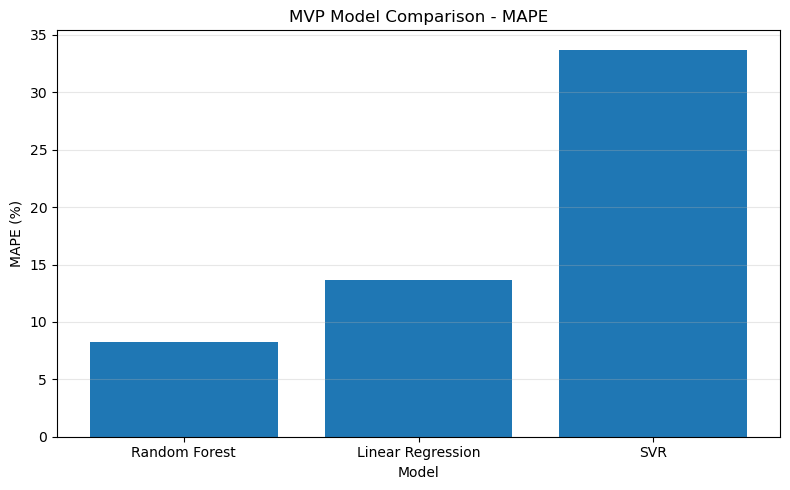

In [60]:
plot_df = mvp_results.sort_values("MAPE (%)")

plt.figure(figsize=(8, 5))
plt.bar(plot_df["Model"], plot_df["MAPE (%)"])

plt.title("MVP Model Comparison - MAPE")
plt.xlabel("Model")
plt.ylabel("MAPE (%)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

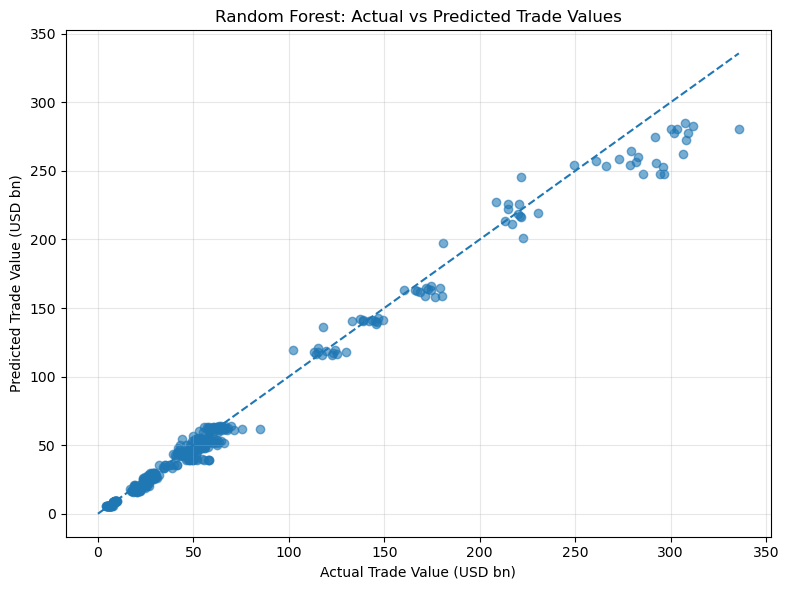

In [61]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_actual / 1_000_000_000,
    rf_pred / 1_000_000_000,
    alpha=0.6
)

max_value = max(
    y_test_actual.max() / 1_000_000_000,
    rf_pred.max() / 1_000_000_000
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.title("Random Forest: Actual vs Predicted Trade Values")
plt.xlabel("Actual Trade Value (USD bn)")
plt.ylabel("Predicted Trade Value (USD bn)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

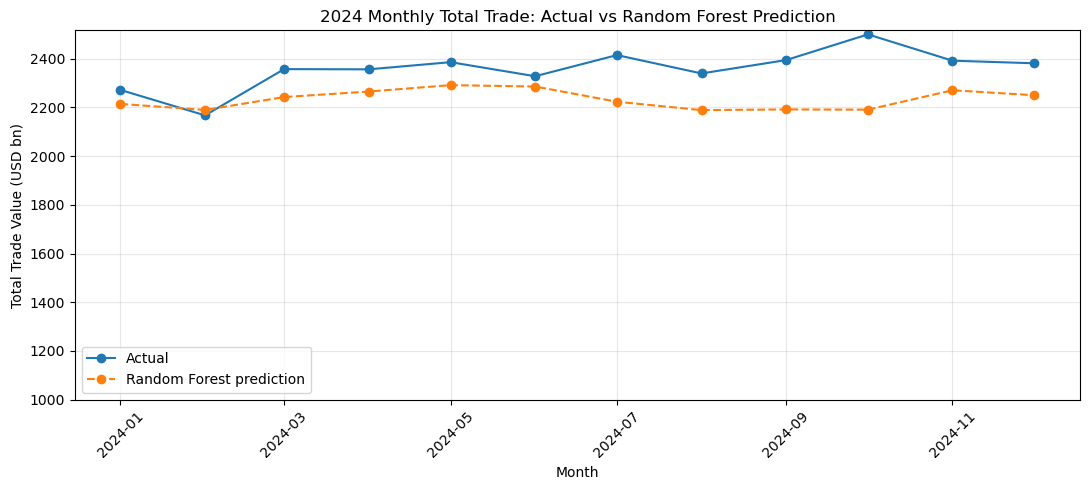

In [62]:
rf_plot_df = test_df[["date"]].copy()

rf_plot_df["Actual Trade Value"] = y_test_actual.values / 1_000_000_000
rf_plot_df["Predicted Trade Value"] = rf_pred / 1_000_000_000

monthly_results = rf_plot_df.groupby("date")[[
    "Actual Trade Value",
    "Predicted Trade Value"
]].sum()

plt.figure(figsize=(11, 5))

plt.plot(
    monthly_results.index,
    monthly_results["Actual Trade Value"],
    marker="o",
    label="Actual"
)

plt.plot(
    monthly_results.index,
    monthly_results["Predicted Trade Value"],
    marker="o",
    linestyle="--",
    label="Random Forest prediction"
)

plt.title("2024 Monthly Total Trade: Actual vs Random Forest Prediction")
plt.xlabel("Month")
plt.ylabel("Total Trade Value (USD bn)")
plt.legend()
plt.grid(alpha=0.3)

plt.ylim(bottom=1000)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

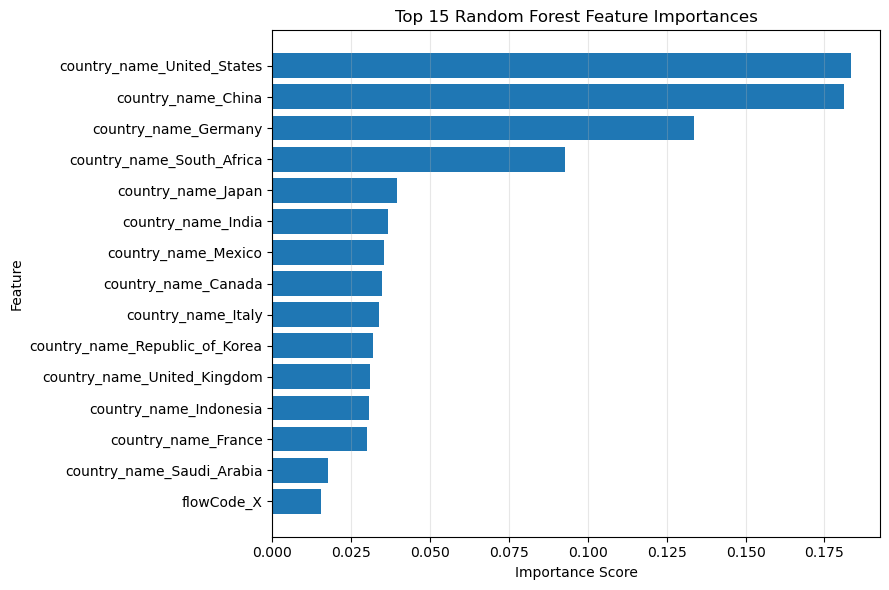

In [63]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

top_features = feature_importance.sort_values(
    "Importance",
    ascending=False
).head(15)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

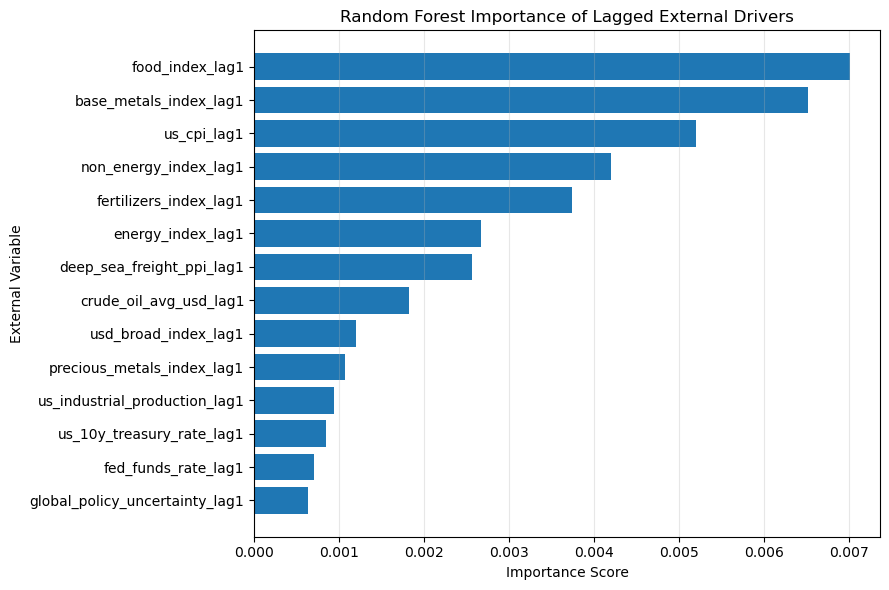

In [64]:
external_importance = feature_importance[
    feature_importance["Feature"].str.endswith("_lag1")
].sort_values("Importance", ascending=False)

plt.figure(figsize=(9, 6))

plt.barh(
    external_importance["Feature"],
    external_importance["Importance"]
)

plt.title("Random Forest Importance of Lagged External Drivers")
plt.xlabel("Importance Score")
plt.ylabel("External Variable")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

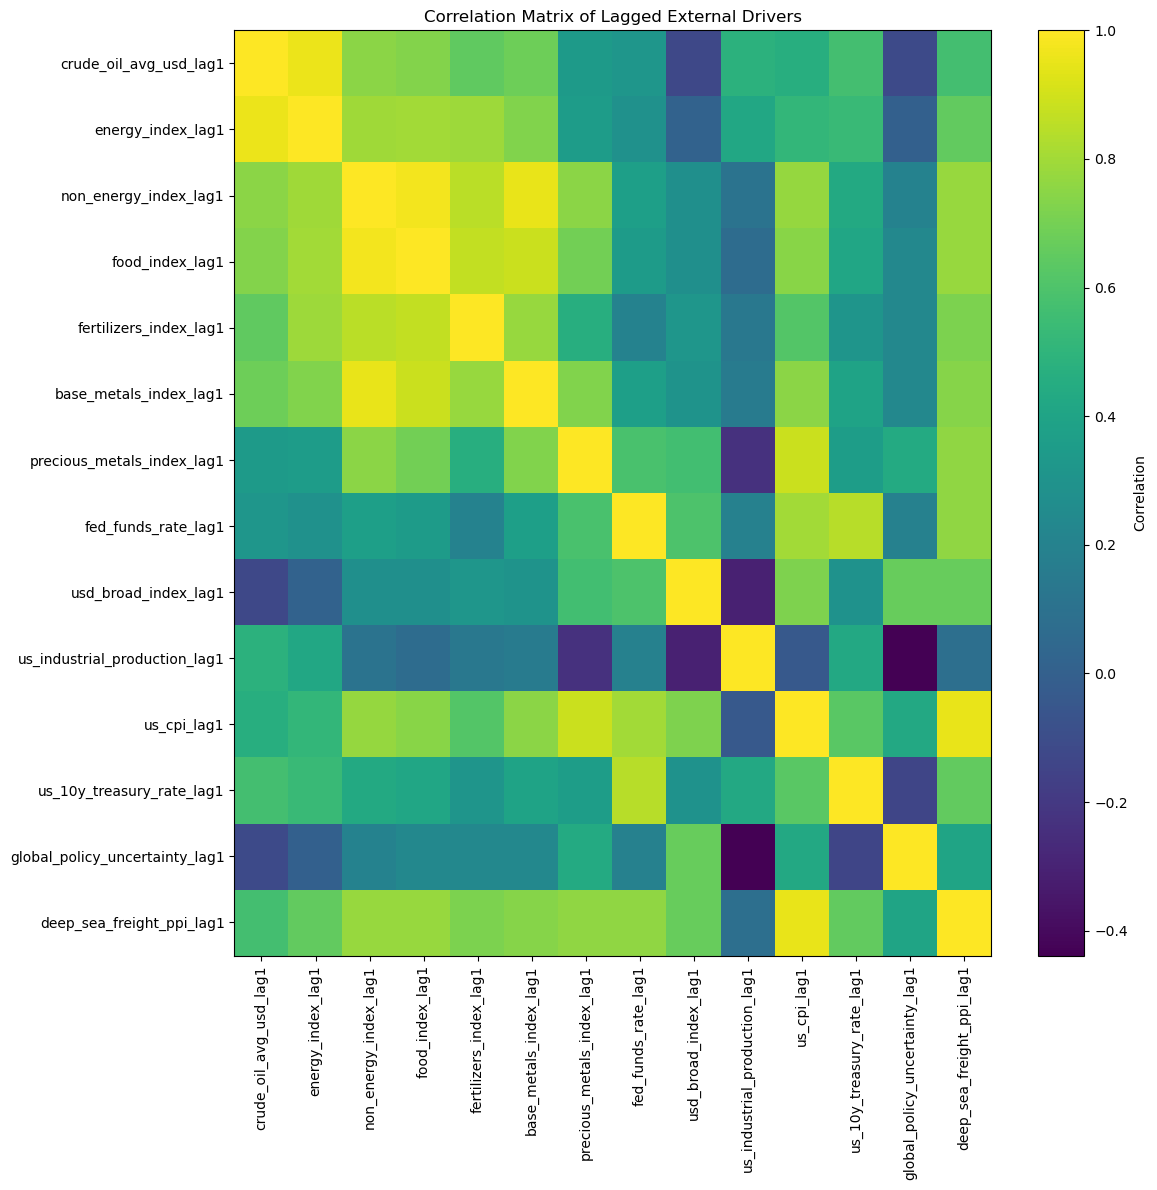

In [65]:
lag_feature_cols = [col + "_lag1" for col in external_cols]

corr_matrix = monthly_external[lag_feature_cols].corr()

plt.figure(figsize=(12, 12))

plt.imshow(corr_matrix, aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(lag_feature_cols)),
    lag_feature_cols,
    rotation=90
)

plt.yticks(
    range(len(lag_feature_cols)),
    lag_feature_cols
)

plt.title("Correlation Matrix of Lagged External Drivers")

plt.tight_layout()
plt.show()

In [66]:
total_2024_trade = y_test_actual.sum()
average_monthly_2024_trade = y_test_actual.groupby(test_df["date"].values).sum().mean()

print(f"Aggregate 2024 test-set trade: USD {total_2024_trade / 1e12:.2f} trillion")
print(f"Average monthly aggregate trade: USD {average_monthly_2024_trade / 1e12:.2f} trillion")

Aggregate 2024 test-set trade: USD 28.29 trillion
Average monthly aggregate trade: USD 2.36 trillion


In [67]:
country_results = pd.DataFrame({
    "Country": model_df.loc[test_df.index, "country_name"].values,
    "Actual": y_test_actual.values,
    "Predicted": rf_pred
})

country_results.head()

,Country,Actual,Predicted
0,Argentina,4.603955e+09,5.482742e+09
1,Argentina,5.412324e+09,5.401876e+09
2,Argentina,4.118057e+09,5.377869e+09
3,Argentina,5.550152e+09,5.365466e+09
4,Argentina,4.331571e+09,5.371091e+09


In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

country_metrics = []

for country in country_results["Country"].unique():
    data = country_results[country_results["Country"] == country]
    
    mae = mean_absolute_error(data["Actual"], data["Predicted"])
    rmse = mean_squared_error(data["Actual"], data["Predicted"]) ** 0.5
    r2 = r2_score(data["Actual"], data["Predicted"])
    mape = (abs((data["Actual"] - data["Predicted"]) / data["Actual"])).mean() * 100
    
    country_metrics.append([country, mae, rmse, r2, mape])

country_metrics_df = pd.DataFrame(
    country_metrics,
    columns=["Country", "MAE", "RMSE", "R2", "MAPE"]
)

country_metrics_df.sort_values("MAPE")

,Country,MAE,RMSE,R2,MAPE
6,Germany,5.903955e+09,7.420039e+09,0.688402,4.729706
1,Australia,1.250613e+09,1.683052e+09,0.344946,4.784260
10,Japan,2.864803e+09,3.445497e+09,0.223137,4.906284
14,South_Africa,4.731656e+08,5.726658e+08,0.311593,5.369288
5,France,3.119840e+09,3.850594e+09,0.600970,5.553551
12,Republic_of_Korea,3.424435e+09,3.817922e+09,-0.584312,6.152983
4,China,1.867282e+10,2.296282e+10,0.751209,6.842120
17,United_States,1.833032e+10,2.319955e+10,0.821826,7.503444
16,United_Kingdom,4.841374e+09,7.031286e+09,0.721865,7.993268
15,Turkiye,2.057798e+09,2.302394e+09,0.646159,8.227904


In [69]:
country_metrics_display = country_metrics_df.copy()

country_metrics_display["MAE_USD_bn"] = country_metrics_display["MAE"] / 1_000_000_000
country_metrics_display["RMSE_USD_bn"] = country_metrics_display["RMSE"] / 1_000_000_000

country_metrics_display = country_metrics_display[
    ["Country", "MAE_USD_bn", "RMSE_USD_bn", "R2", "MAPE"]
]

country_metrics_display = country_metrics_display.sort_values("MAPE")

country_metrics_display.round(2)

,Country,MAE_USD_bn,RMSE_USD_bn,R2,MAPE
6,Germany,5.90,7.42,0.69,4.73
1,Australia,1.25,1.68,0.34,4.78
10,Japan,2.86,3.45,0.22,4.91
14,South_Africa,0.47,0.57,0.31,5.37
5,France,3.12,3.85,0.60,5.55
12,Republic_of_Korea,3.42,3.82,-0.58,6.15
4,China,18.67,22.96,0.75,6.84
17,United_States,18.33,23.20,0.82,7.50
16,United_Kingdom,4.84,7.03,0.72,7.99
15,Turkiye,2.06,2.30,0.65,8.23


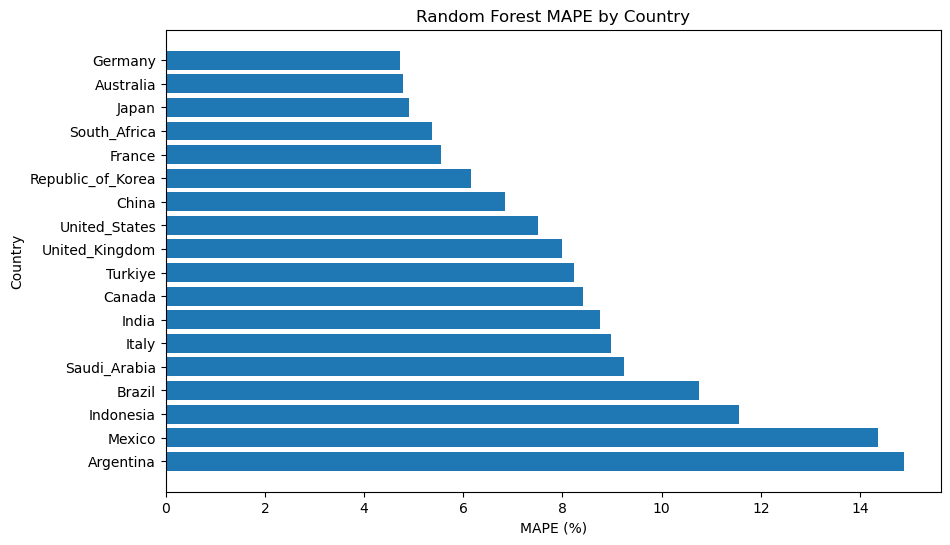

In [70]:
import matplotlib.pyplot as plt

plot_data = country_metrics_display.sort_values("MAPE", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(plot_data["Country"], plot_data["MAPE"])
plt.xlabel("MAPE (%)")
plt.ylabel("Country")
plt.title("Random Forest MAPE by Country")
plt.show()

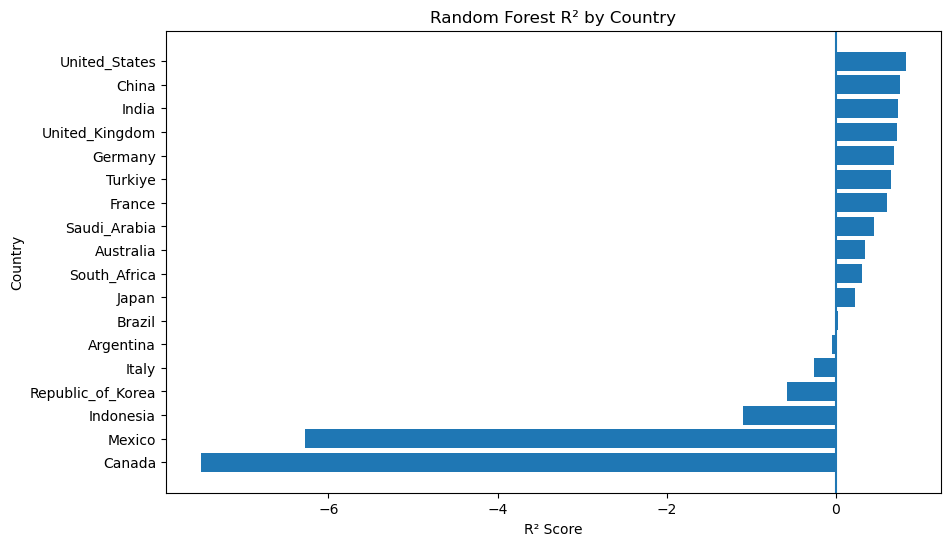

In [71]:
plot_data = country_metrics_display.sort_values("R2")

plt.figure(figsize=(10, 6))
plt.barh(plot_data["Country"], plot_data["R2"])
plt.axvline(0)
plt.xlabel("R² Score")
plt.ylabel("Country")
plt.title("Random Forest R² by Country")
plt.show()

In [72]:
canada_results = country_results[country_results["Country"] == "Canada"]

canada_results

,Country,Actual,Predicted
72,Canada,4.186179e+10,4.506149e+10
73,Canada,4.533378e+10,4.536258e+10
74,Canada,4.427826e+10,4.483295e+10
75,Canada,4.549343e+10,4.526057e+10
76,Canada,4.775550e+10,4.502239e+10
77,Canada,4.738599e+10,4.558485e+10
78,Canada,4.784127e+10,4.506841e+10
79,Canada,4.712502e+10,4.581764e+10
80,Canada,4.830561e+10,4.510306e+10
81,Canada,4.777392e+10,4.600549e+10


In [73]:
country_results["Date"] = model_df.loc[test_df.index, "date"].values
country_results["Flow"] = model_df.loc[test_df.index, "flowDesc"].values

canada_results = country_results[country_results["Country"] == "Canada"]

canada_results[["Date", "Flow", "Actual", "Predicted"]]

,Date,Flow,Actual,Predicted
72,2024-01-01,Import,4.186179e+10,4.506149e+10
73,2024-01-01,Export,4.533378e+10,4.536258e+10
74,2024-02-01,Import,4.427826e+10,4.483295e+10
75,2024-02-01,Export,4.549343e+10,4.526057e+10
76,2024-03-01,Import,4.775550e+10,4.502239e+10
77,2024-03-01,Export,4.738599e+10,4.558485e+10
78,2024-04-01,Import,4.784127e+10,4.506841e+10
79,2024-04-01,Export,4.712502e+10,4.581764e+10
80,2024-05-01,Import,4.830561e+10,4.510306e+10
81,2024-05-01,Export,4.777392e+10,4.600549e+10


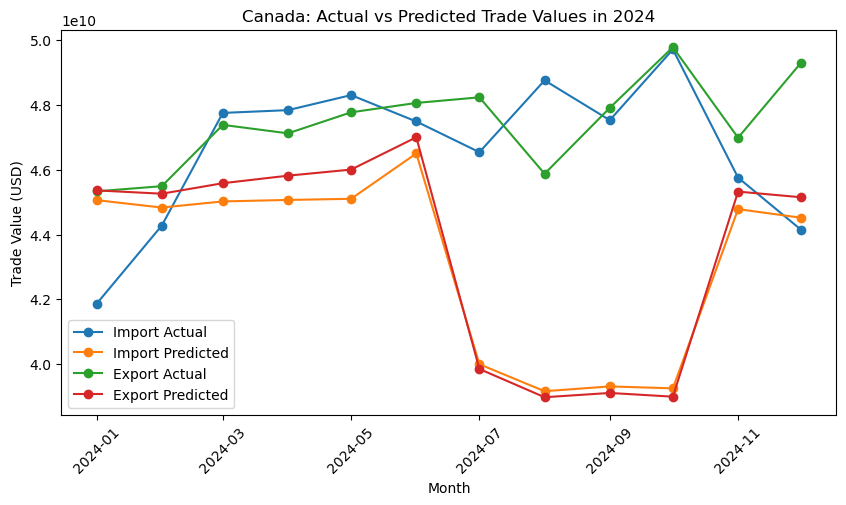

In [74]:
canada_imports = canada_results[canada_results["Flow"] == "Import"]
canada_exports = canada_results[canada_results["Flow"] == "Export"]

plt.figure(figsize=(10, 5))

plt.plot(canada_imports["Date"], canada_imports["Actual"], marker="o", label="Import Actual")
plt.plot(canada_imports["Date"], canada_imports["Predicted"], marker="o", label="Import Predicted")

plt.plot(canada_exports["Date"], canada_exports["Actual"], marker="o", label="Export Actual")
plt.plot(canada_exports["Date"], canada_exports["Predicted"], marker="o", label="Export Predicted")

plt.title("Canada: Actual vs Predicted Trade Values in 2024")
plt.xlabel("Month")
plt.ylabel("Trade Value (USD)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [75]:
canada_features = model_df[
    (model_df["country_name"] == "Canada") &
    (model_df["date"].dt.year == 2024)
]

canada_features[
    ["date", "crude_oil_avg_usd_lag1", "energy_index_lag1",
     "non_energy_index_lag1", "usd_broad_index_lag1",
     "us_industrial_production_lag1"]
].drop_duplicates()

,date,crude_oil_avg_usd_lag1,energy_index_lag1,non_energy_index_lag1,usd_broad_index_lag1,us_industrial_production_lag1
1032,2024-01-01,75.7193,99.6082,107.7589,119.833140,100.6031
1034,2024-02-01,77.6723,101.1793,107.1870,120.227357,99.2223
1036,2024-03-01,80.5480,102.2207,107.4910,121.065940,100.2850
1038,2024-04-01,83.5457,104.2348,109.9114,120.658833,100.4575
1040,2024-05-01,88.0113,109.5944,115.5760,122.142814,100.2434
1042,2024-06-01,81.4450,102.6190,115.5886,121.858341,100.8630
1044,2024-07-01,81.2050,103.7664,114.1568,123.709479,100.8940
1046,2024-08-01,83.2587,105.9796,111.7083,123.382436,99.9757
1048,2024-09-01,78.1210,102.6462,109.6065,122.613741,100.4309
1050,2024-10-01,72.4243,95.3732,112.1884,121.884855,99.8084


In [76]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance.sort_values("Importance", ascending=False).head(15)

,Feature,Importance
33,country_name_United_States,0.183427
20,country_name_China,0.181103
22,country_name_Germany,0.133624
30,country_name_South_Africa,0.092638
26,country_name_Japan,0.039658
23,country_name_India,0.036825
27,country_name_Mexico,0.035554
19,country_name_Canada,0.034836
25,country_name_Italy,0.033837
28,country_name_Republic_of_Korea,0.031928


In [77]:
non_country_features = feature_importance[
    ~feature_importance["Feature"].str.contains("country_name")
]

non_country_features.sort_values("Importance", ascending=False).head(15)

,Feature,Importance
34,flowCode_X,0.015541
6,food_index_lag1,0.007018
8,base_metals_index_lag1,0.006526
13,us_cpi_lag1,0.005197
5,non_energy_index_lag1,0.004201
7,fertilizers_index_lag1,0.003742
4,energy_index_lag1,0.002668
16,deep_sea_freight_ppi_lag1,0.002570
3,crude_oil_avg_usd_lag1,0.001821
11,usd_broad_index_lag1,0.001200


In [78]:
[col for col in X_train.columns if "lag" in col.lower()]

['crude_oil_avg_usd_lag1',
 'energy_index_lag1',
 'non_energy_index_lag1',
 'food_index_lag1',
 'fertilizers_index_lag1',
 'base_metals_index_lag1',
 'precious_metals_index_lag1',
 'fed_funds_rate_lag1',
 'usd_broad_index_lag1',
 'us_industrial_production_lag1',
 'us_cpi_lag1',
 'us_10y_treasury_rate_lag1',
 'global_policy_uncertainty_lag1',
 'deep_sea_freight_ppi_lag1']

In [79]:
# Saving current Random Forest result (external only)

rf_baseline_predictions = country_results.copy()
rf_baseline_country_metrics = country_metrics_display.copy()

print("Baseline Random Forest results saved.")

Baseline Random Forest results saved.


In [80]:
model_df = model_df.sort_values(
    ["country_name", "flowCode", "date"]
).copy()

model_df["trade_value_lag12"] = model_df.groupby(
    ["country_name", "flowCode"]
)["primaryValue"].shift(12)

model_df[
    ["country_name", "flowDesc", "date", "primaryValue", "trade_value_lag12"]
].head(15)

,country_name,flowDesc,date,primaryValue,trade_value_lag12
2,Argentina,Import,2014-02-01,5.539307e+09,NaN
4,Argentina,Import,2014-03-01,5.524368e+09,NaN
6,Argentina,Import,2014-04-01,5.414486e+09,NaN
8,Argentina,Import,2014-05-01,5.760059e+09,NaN
10,Argentina,Import,2014-06-01,5.979561e+09,NaN
12,Argentina,Import,2014-07-01,5.898326e+09,NaN
14,Argentina,Import,2014-08-01,5.638072e+09,NaN
16,Argentina,Import,2014-09-01,5.495982e+09,NaN
18,Argentina,Import,2014-10-01,5.514950e+09,NaN
20,Argentina,Import,2014-11-01,4.762304e+09,NaN


In [81]:
seasonal_model_df = model_df.dropna(subset=["trade_value_lag12"]).copy()

print("Rows before:", len(model_df))
print("Rows after:", len(seasonal_model_df))
print("Missing lag values:", seasonal_model_df["trade_value_lag12"].isna().sum())

Rows before: 4636
Rows after: 4204
Missing lag values: 0


In [82]:
seasonal_model_df_encoded = pd.get_dummies(
    seasonal_model_df,
    columns=["country_name", "flowCode"],
    drop_first=True
)

print("Seasonal model shape:", seasonal_model_df_encoded.shape)

Seasonal model shape: (4204, 41)


In [83]:
seasonal_train_df = seasonal_model_df_encoded[
    seasonal_model_df_encoded["year"] <= 2023
]

seasonal_test_df = seasonal_model_df_encoded[
    seasonal_model_df_encoded["year"] == 2024
]

print("Seasonal train shape:", seasonal_train_df.shape)
print("Seasonal test shape:", seasonal_test_df.shape)

Seasonal train shape: (3772, 41)
Seasonal test shape: (432, 41)


In [84]:
seasonal_drop_cols = [
    "primaryValue",
    "log_primaryValue",
    "date",
    "period",
    "flowDesc"
]

X_train_seasonal = seasonal_train_df.drop(columns=seasonal_drop_cols)
y_train_seasonal = seasonal_train_df["log_primaryValue"]

X_test_seasonal = seasonal_test_df.drop(columns=seasonal_drop_cols)
y_test_seasonal = seasonal_test_df["log_primaryValue"]

print("X_train seasonal shape:", X_train_seasonal.shape)
print("X_test seasonal shape:", X_test_seasonal.shape)

X_train seasonal shape: (3772, 36)
X_test seasonal shape: (432, 36)


In [85]:
"trade_value_lag12" in X_train_seasonal.columns

True

In [86]:
from sklearn.ensemble import RandomForestRegressor

rf_seasonal = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_seasonal.fit(X_train_seasonal, y_train_seasonal)

seasonal_pred_log = rf_seasonal.predict(X_test_seasonal)

print("Seasonal Random Forest trained.")

Seasonal Random Forest trained.


In [87]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Converting predictions and actual values back from log scale
seasonal_pred = np.expm1(seasonal_pred_log)
seasonal_actual = np.expm1(y_test_seasonal)

# Calculating evaluation metrics
seasonal_mae = mean_absolute_error(seasonal_actual, seasonal_pred)

seasonal_rmse = np.sqrt(
    mean_squared_error(seasonal_actual, seasonal_pred)
)

seasonal_r2 = r2_score(seasonal_actual, seasonal_pred)

seasonal_mape = (
    abs((seasonal_actual - seasonal_pred) / seasonal_actual).mean() * 100
)

In [88]:
# Display results
print("Seasonal Random Forest results")
print("MAE:", seasonal_mae)
print("RMSE:", seasonal_rmse)
print("R2:", seasonal_r2)
print("MAPE:", seasonal_mape)

Seasonal Random Forest results
MAE: 3881051913.634185
RMSE: 6868072604.1856985
R2: 0.9904315667611719
MAPE: 6.568867460265857


In [89]:
seasonal_country_results = pd.DataFrame({
    "Country": seasonal_model_df.loc[seasonal_test_df.index, "country_name"].values,
    "Actual": seasonal_actual.values,
    "Predicted": seasonal_pred
})

seasonal_country_results.head()

,Country,Actual,Predicted
0,Argentina,4.603955e+09,5.239486e+09
1,Argentina,4.118057e+09,4.948272e+09
2,Argentina,4.331571e+09,5.995441e+09
3,Argentina,4.704521e+09,5.718709e+09
4,Argentina,5.012117e+09,6.416580e+09


In [90]:
seasonal_country_metrics = []

In [91]:
for country in seasonal_country_results["Country"].unique():
    data = seasonal_country_results[
        seasonal_country_results["Country"] == country
    ]
    
    print(country, len(data))

Argentina 24
Australia 24
Brazil 24
Canada 24
China 24
France 24
Germany 24
India 24
Indonesia 24
Italy 24
Japan 24
Mexico 24
Republic_of_Korea 24
Saudi_Arabia 24
South_Africa 24
Turkiye 24
United_Kingdom 24
United_States 24


In [92]:
argentina_data = seasonal_country_results[
    seasonal_country_results["Country"] == "Argentina"
]

argentina_mae = mean_absolute_error(
    argentina_data["Actual"],
    argentina_data["Predicted"]
)

argentina_rmse = np.sqrt(
    mean_squared_error(
        argentina_data["Actual"],
        argentina_data["Predicted"]
    )
)

argentina_r2 = r2_score(
    argentina_data["Actual"],
    argentina_data["Predicted"]
)

argentina_mape = (
    abs(
        (argentina_data["Actual"] - argentina_data["Predicted"])
        / argentina_data["Actual"]
    ).mean()
    * 100
)

In [93]:
print("Argentina MAE:", argentina_mae)
print("Argentina RMSE:", argentina_rmse)
print("Argentina R2:", argentina_r2)
print("Argentina MAPE:", argentina_mape)

Argentina MAE: 864795205.0899967
Argentina RMSE: 1001359984.5164604
Argentina R2: -0.00617598154920862
Argentina MAPE: 15.509579217055839


In [94]:
for country in seasonal_country_results["Country"].unique():
    data = seasonal_country_results[
        seasonal_country_results["Country"] == country
    ]
    
    mae = mean_absolute_error(data["Actual"], data["Predicted"])
    
    seasonal_country_metrics.append([country, mae])

seasonal_country_metrics[:5]

[['Argentina', 864795205.0899967],
 ['Australia', 1311601299.8631005],
 ['Brazil', 2557683175.3142095],
 ['Canada', 1835625234.5023158],
 ['China', 12868092739.26339]]

In [95]:
seasonal_country_metrics = []

In [96]:
for country in seasonal_country_results["Country"].unique():
    data = seasonal_country_results[
        seasonal_country_results["Country"] == country
    ]
    
    mae = mean_absolute_error(data["Actual"], data["Predicted"])
    
    rmse = np.sqrt(
        mean_squared_error(data["Actual"], data["Predicted"])
    )
    
    seasonal_country_metrics.append([country, mae, rmse])

seasonal_country_metrics[:5]

[['Argentina', 864795205.0899967, np.float64(1001359984.5164604)],
 ['Australia', 1311601299.8631005, np.float64(1538033049.1086264)],
 ['Brazil', 2557683175.3142095, np.float64(3183982335.183797)],
 ['Canada', 1835625234.5023158, np.float64(2235283075.309699)],
 ['China', 12868092739.26339, np.float64(16524529263.628101)]]

In [97]:
seasonal_country_metrics = []

In [98]:
for country in seasonal_country_results["Country"].unique():
    data = seasonal_country_results[
        seasonal_country_results["Country"] == country
    ]
    
    mae = mean_absolute_error(data["Actual"], data["Predicted"])
    
    rmse = np.sqrt(
        mean_squared_error(data["Actual"], data["Predicted"])
    )
    
    r2 = r2_score(data["Actual"], data["Predicted"])
    
    seasonal_country_metrics.append([country, mae, rmse, r2])

seasonal_country_metrics[:5]

[['Argentina',
  864795205.0899967,
  np.float64(1001359984.5164604),
  -0.00617598154920862],
 ['Australia',
  1311601299.8631005,
  np.float64(1538033049.1086264),
  0.45296680498435693],
 ['Brazil',
  2557683175.3142095,
  np.float64(3183982335.183797),
  0.035512777944363805],
 ['Canada',
  1835625234.5023158,
  np.float64(2235283075.309699),
  -0.47504751961056235],
 ['China',
  12868092739.26339,
  np.float64(16524529263.628101),
  0.8711623341006202]]

In [99]:
seasonal_country_metrics = []

In [100]:
for country in seasonal_country_results["Country"].unique():
    data = seasonal_country_results[
        seasonal_country_results["Country"] == country
    ]
    
    mae = mean_absolute_error(data["Actual"], data["Predicted"])
    
    rmse = np.sqrt(
        mean_squared_error(data["Actual"], data["Predicted"])
    )
    
    r2 = r2_score(data["Actual"], data["Predicted"])
    
    mape = (
        abs(
            (data["Actual"] - data["Predicted"])
            / data["Actual"]
        ).mean()
        * 100
    )
    
    seasonal_country_metrics.append(
        [country, mae, rmse, r2, mape]
    )

seasonal_country_metrics[:5]

[['Argentina',
  864795205.0899967,
  np.float64(1001359984.5164604),
  -0.00617598154920862,
  np.float64(15.509579217055839)],
 ['Australia',
  1311601299.8631005,
  np.float64(1538033049.1086264),
  0.45296680498435693,
  np.float64(5.014861882103149)],
 ['Brazil',
  2557683175.3142095,
  np.float64(3183982335.183797),
  0.035512777944363805,
  np.float64(9.930938813853981)],
 ['Canada',
  1835625234.5023158,
  np.float64(2235283075.309699),
  -0.47504751961056235,
  np.float64(3.871769452650827)],
 ['China',
  12868092739.26339,
  np.float64(16524529263.628101),
  0.8711623341006202,
  np.float64(4.839730250039447)]]

In [101]:
seasonal_country_metrics_df = pd.DataFrame(
    seasonal_country_metrics,
    columns=["Country", "MAE", "RMSE", "R2", "MAPE"]
)

seasonal_country_metrics_df["MAE_USD_bn"] = (
    seasonal_country_metrics_df["MAE"] / 1_000_000_000
)

seasonal_country_metrics_df["RMSE_USD_bn"] = (
    seasonal_country_metrics_df["RMSE"] / 1_000_000_000
)

seasonal_country_metrics_display = seasonal_country_metrics_df[
    ["Country", "MAE_USD_bn", "RMSE_USD_bn", "R2", "MAPE"]
]

seasonal_country_metrics_display.sort_values("MAPE").round(2)

,Country,MAE_USD_bn,RMSE_USD_bn,R2,MAPE
3,Canada,1.84,2.24,-0.48,3.87
5,France,2.35,2.80,0.79,4.05
10,Japan,2.57,2.97,0.42,4.23
9,Italy,2.53,3.23,0.60,4.65
4,China,12.87,16.52,0.87,4.84
17,United_States,12.68,17.20,0.90,5.00
1,Australia,1.31,1.54,0.45,5.01
15,Turkiye,1.33,1.72,0.80,5.20
8,Indonesia,1.25,1.54,0.45,5.86
14,South_Africa,0.53,0.62,0.20,5.94


In [102]:
comparison_mape = rf_baseline_country_metrics[
    ["Country", "MAPE", "R2"]
].merge(
    seasonal_country_metrics_display[
        ["Country", "MAPE", "R2"]
    ],
    on="Country",
    suffixes=("_Baseline", "_Seasonal")
)

comparison_mape["MAPE_Change"] = (
    comparison_mape["MAPE_Seasonal"]
    - comparison_mape["MAPE_Baseline"]
)

comparison_mape["R2_Change"] = (
    comparison_mape["R2_Seasonal"]
    - comparison_mape["R2_Baseline"]
)

comparison_mape.sort_values("MAPE_Change").round(2)

,Country,MAPE_Baseline,R2_Baseline,MAPE_Seasonal,R2_Seasonal,MAPE_Change,R2_Change
16,Mexico,14.35,-6.27,6.54,-0.46,-7.82,5.81
15,Indonesia,11.56,-1.10,5.86,0.45,-5.70,1.55
10,Canada,8.41,-7.51,3.87,-0.48,-4.53,7.03
12,Italy,8.98,-0.26,4.65,0.60,-4.32,0.86
13,Saudi_Arabia,9.24,0.45,6.00,0.73,-3.24,0.28
9,Turkiye,8.23,0.65,5.20,0.80,-3.03,0.16
7,United_States,7.50,0.82,5.00,0.90,-2.50,0.08
6,China,6.84,0.75,4.84,0.87,-2.00,0.12
4,France,5.55,0.60,4.05,0.79,-1.50,0.19
11,India,8.75,0.74,7.52,0.83,-1.23,0.10


In [103]:
model_df["lag12_date"] = model_df.groupby(
    ["country_name", "flowCode"]
)["date"].shift(12)

wrong_lag_rows = model_df[
    model_df["trade_value_lag12"].notna()
    & (
        model_df["lag12_date"]
        != model_df["date"] - pd.DateOffset(years=1)
    )
]

print("Rows where lag12 is not exactly one year earlier:", len(wrong_lag_rows))

Rows where lag12 is not exactly one year earlier: 66


In [104]:
model_df = model_df.drop(
    columns=["trade_value_lag12", "lag12_date"],
    errors="ignore"
)

In [105]:
lag_lookup = model_df[
    ["country_name", "flowCode", "date", "primaryValue"]
].copy()

lag_lookup["date"] = lag_lookup["date"] + pd.DateOffset(years=1)

lag_lookup = lag_lookup.rename(
    columns={"primaryValue": "trade_value_lag12"}
)

lag_lookup.head()

,country_name,flowCode,date,trade_value_lag12
2,Argentina,M,2015-02-01,5.539307e+09
4,Argentina,M,2015-03-01,5.524368e+09
6,Argentina,M,2015-04-01,5.414486e+09
8,Argentina,M,2015-05-01,5.760059e+09
10,Argentina,M,2015-06-01,5.979561e+09


In [106]:
model_df = model_df.merge(
    lag_lookup,
    on=["country_name", "flowCode", "date"],
    how="left"
)

model_df[
    ["country_name", "flowDesc", "date", "primaryValue", "trade_value_lag12"]
].head(15)

,country_name,flowDesc,date,primaryValue,trade_value_lag12
0,Argentina,Import,2014-02-01,5.539307e+09,NaN
1,Argentina,Import,2014-03-01,5.524368e+09,NaN
2,Argentina,Import,2014-04-01,5.414486e+09,NaN
3,Argentina,Import,2014-05-01,5.760059e+09,NaN
4,Argentina,Import,2014-06-01,5.979561e+09,NaN
5,Argentina,Import,2014-07-01,5.898326e+09,NaN
6,Argentina,Import,2014-08-01,5.638072e+09,NaN
7,Argentina,Import,2014-09-01,5.495982e+09,NaN
8,Argentina,Import,2014-10-01,5.514950e+09,NaN
9,Argentina,Import,2014-11-01,4.762304e+09,NaN


In [107]:
print("Rows with a true 12-month lag:", model_df["trade_value_lag12"].notna().sum())
print("Rows without a true 12-month lag:", model_df["trade_value_lag12"].isna().sum())

Rows with a true 12-month lag: 4196
Rows without a true 12-month lag: 440


In [108]:
seasonal_model_df = model_df.dropna(
    subset=["trade_value_lag12"]
).copy()

print("Rows kept for seasonal model:", len(seasonal_model_df))


Rows kept for seasonal model: 4196


In [109]:
seasonal_model_df_encoded = pd.get_dummies(
    seasonal_model_df,
    columns=["country_name", "flowCode"],
    drop_first=True
)

print("Seasonal model shape:", seasonal_model_df_encoded.shape)

Seasonal model shape: (4196, 41)


In [110]:
seasonal_train_df = seasonal_model_df_encoded[
    seasonal_model_df_encoded["year"] <= 2023
]

seasonal_test_df = seasonal_model_df_encoded[
    seasonal_model_df_encoded["year"] == 2024
]

print("Seasonal train shape:", seasonal_train_df.shape)
print("Seasonal test shape:", seasonal_test_df.shape)

Seasonal train shape: (3764, 41)
Seasonal test shape: (432, 41)


In [111]:
seasonal_drop_cols = [
    "primaryValue",
    "log_primaryValue",
    "date",
    "period",
    "flowDesc"
]

X_train_seasonal = seasonal_train_df.drop(
    columns=seasonal_drop_cols
)

X_test_seasonal = seasonal_test_df.drop(
    columns=seasonal_drop_cols
)

y_train_seasonal = seasonal_train_df["log_primaryValue"]
y_test_seasonal = seasonal_test_df["log_primaryValue"]

print("X_train shape:", X_train_seasonal.shape)
print("X_test shape:", X_test_seasonal.shape)

X_train shape: (3764, 36)
X_test shape: (432, 36)


In [112]:
"trade_value_lag12" in X_train_seasonal.columns

True

In [113]:
rf_seasonal = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_seasonal.fit(X_train_seasonal, y_train_seasonal)

seasonal_pred_log = rf_seasonal.predict(X_test_seasonal)

print("Corrected seasonal Random Forest trained.")

Corrected seasonal Random Forest trained.


In [114]:
seasonal_pred = np.expm1(seasonal_pred_log)

seasonal_actual = np.expm1(y_test_seasonal)

In [115]:
seasonal_mae = mean_absolute_error(
    seasonal_actual,
    seasonal_pred
)

print("Corrected seasonal MAE:", seasonal_mae)

Corrected seasonal MAE: 3937994096.0206594


In [116]:
seasonal_rmse = np.sqrt(
    mean_squared_error(
        seasonal_actual,
        seasonal_pred
    )
)

print("Corrected seasonal RMSE:", seasonal_rmse)

Corrected seasonal RMSE: 6945299567.250754


In [117]:
seasonal_r2 = r2_score(
    seasonal_actual,
    seasonal_pred
)

print("Corrected seasonal R2:", seasonal_r2)

Corrected seasonal R2: 0.9902151754862534


In [118]:
seasonal_mape = (
    abs(
        (seasonal_actual - seasonal_pred)
        / seasonal_actual
    ).mean()
    * 100
)

print("Corrected seasonal MAPE:", seasonal_mape)

Corrected seasonal MAPE: 6.658806192593267


In [119]:
overall_model_comparison = pd.DataFrame({
    "Model": [
        "External-only Random Forest",
        "Random Forest with true 12-month seasonal lag"
    ],
    "MAE_USD_bn": [
        5.020901563862077,
        seasonal_mae / 1_000_000_000
    ],
    "RMSE_USD_bn": [
        8.941761374174374,
        seasonal_rmse / 1_000_000_000
    ],
    "R2": [
        0.9837812556741437,
        seasonal_r2
    ],
    "MAPE": [
        8.277434387115946,
        seasonal_mape
    ]
})

overall_model_comparison.round(2)

,Model,MAE_USD_bn,RMSE_USD_bn,R2,MAPE
0,External-only Random Forest,5.02,8.94,0.98,8.28
1,Random Forest with true 12-month seasonal lag,3.94,6.95,0.99,6.66


In [120]:
seasonal_country_results = pd.DataFrame({
    "Country": seasonal_model_df.loc[
        seasonal_test_df.index, "country_name"
    ].values,
    "Actual": np.asarray(seasonal_actual),
    "Predicted": seasonal_pred
})

seasonal_country_results.head()

,Country,Actual,Predicted
0,Argentina,4.603955e+09,5.201057e+09
1,Argentina,4.118057e+09,4.970995e+09
2,Argentina,4.331571e+09,5.997760e+09
3,Argentina,4.704521e+09,5.770657e+09
4,Argentina,5.012117e+09,6.521666e+09


In [121]:
corrected_seasonal_country_metrics = []

In [122]:
for country in seasonal_country_results["Country"].unique():
    data = seasonal_country_results[
        seasonal_country_results["Country"] == country
    ]
    
    mae = mean_absolute_error(data["Actual"], data["Predicted"])
    
    rmse = np.sqrt(
        mean_squared_error(data["Actual"], data["Predicted"])
    )
    
    r2 = r2_score(data["Actual"], data["Predicted"])
    
    mape = (
        abs(
            (data["Actual"] - data["Predicted"])
            / data["Actual"]
        ).mean()
        * 100
    )
    
    corrected_seasonal_country_metrics.append(
        [country, mae, rmse, r2, mape]
    )

corrected_seasonal_country_metrics[:5]

[['Argentina',
  914139842.906263,
  np.float64(1053523765.2697524),
  -0.11373573539251014,
  np.float64(16.41220552031587)],
 ['Australia',
  1304108630.3919902,
  np.float64(1517828061.3681855),
  0.4672450407384384,
  np.float64(4.988779202250356)],
 ['Brazil',
  2486543836.663504,
  np.float64(3121559529.178773),
  0.07296010981295242,
  np.float64(9.653353167718986)],
 ['Canada',
  1834180624.4694698,
  np.float64(2322663568.4438624),
  -0.5926251437436669,
  np.float64(3.8648279091833895)],
 ['China',
  13308811341.265732,
  np.float64(17035388350.812773),
  0.8630731137780173,
  np.float64(4.977313778867717)]]

In [123]:
corrected_seasonal_country_metrics_df = pd.DataFrame(
    corrected_seasonal_country_metrics,
    columns=["Country", "MAE", "RMSE", "R2", "MAPE"]
)

corrected_seasonal_country_metrics_df["MAE_USD_bn"] = (
    corrected_seasonal_country_metrics_df["MAE"] / 1_000_000_000
)

corrected_seasonal_country_metrics_df["RMSE_USD_bn"] = (
    corrected_seasonal_country_metrics_df["RMSE"] / 1_000_000_000
)

corrected_seasonal_country_metrics_display = (
    corrected_seasonal_country_metrics_df[
        ["Country", "MAE_USD_bn", "RMSE_USD_bn", "R2", "MAPE"]
    ]
)

corrected_seasonal_country_metrics_display.sort_values("MAPE").round(2)

,Country,MAE_USD_bn,RMSE_USD_bn,R2,MAPE
3,Canada,1.83,2.32,-0.59,3.86
5,France,2.50,2.96,0.76,4.30
10,Japan,2.69,3.12,0.36,4.43
9,Italy,2.61,3.30,0.58,4.80
17,United_States,12.45,17.00,0.90,4.89
4,China,13.31,17.04,0.86,4.98
1,Australia,1.30,1.52,0.47,4.99
15,Turkiye,1.33,1.71,0.80,5.19
14,South_Africa,0.49,0.58,0.28,5.55
13,Saudi_Arabia,1.31,1.66,0.75,5.79


In [124]:
corrected_comparison = rf_baseline_country_metrics[
    ["Country", "MAPE", "R2"]
].merge(
    corrected_seasonal_country_metrics_display[
        ["Country", "MAPE", "R2"]
    ],
    on="Country",
    suffixes=("_Baseline", "_Seasonal")
)

corrected_comparison.head()

,Country,MAPE_Baseline,R2_Baseline,MAPE_Seasonal,R2_Seasonal
0,Germany,4.729706,0.688402,6.410201,0.407491
1,Australia,4.784260,0.344946,4.988779,0.467245
2,Japan,4.906284,0.223137,4.426631,0.362621
3,South_Africa,5.369288,0.311593,5.554117,0.284103
4,France,5.553551,0.600970,4.295420,0.764908


In [125]:
corrected_comparison["MAPE_Change"] = (
    corrected_comparison["MAPE_Seasonal"]
    - corrected_comparison["MAPE_Baseline"]
)

corrected_comparison["R2_Change"] = (
    corrected_comparison["R2_Seasonal"]
    - corrected_comparison["R2_Baseline"]
)

In [126]:
corrected_comparison.sort_values("MAPE_Change").round(2)

,Country,MAPE_Baseline,R2_Baseline,MAPE_Seasonal,R2_Seasonal,MAPE_Change,R2_Change
16,Mexico,14.35,-6.27,6.75,-0.58,-7.60,5.69
15,Indonesia,11.56,-1.10,6.01,0.42,-5.55,1.52
10,Canada,8.41,-7.51,3.86,-0.59,-4.54,6.91
12,Italy,8.98,-0.26,4.80,0.58,-4.18,0.85
13,Saudi_Arabia,9.24,0.45,5.79,0.75,-3.45,0.30
9,Turkiye,8.23,0.65,5.19,0.80,-3.03,0.16
7,United_States,7.50,0.82,4.89,0.90,-2.61,0.08
6,China,6.84,0.75,4.98,0.86,-1.86,0.11
4,France,5.55,0.60,4.30,0.76,-1.26,0.16
11,India,8.75,0.74,7.51,0.83,-1.24,0.09


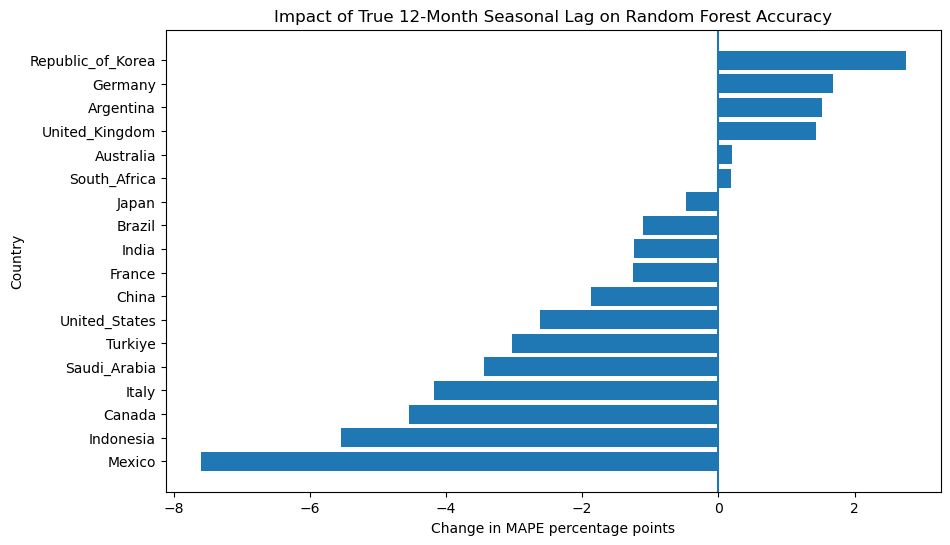

In [127]:
plot_data = corrected_comparison.sort_values("MAPE_Change")

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Country"],
    plot_data["MAPE_Change"]
)

plt.axvline(0)

plt.xlabel("Change in MAPE percentage points")
plt.ylabel("Country")
plt.title("Impact of True 12-Month Seasonal Lag on Random Forest Accuracy")

plt.show()

In [128]:
X_train_matched_external = X_train_seasonal.drop(
    columns=["trade_value_lag12"]
)

X_test_matched_external = X_test_seasonal.drop(
    columns=["trade_value_lag12"]
)

print(X_train_matched_external.shape)
print(X_test_matched_external.shape)

(3764, 35)
(432, 35)


In [129]:
rf_matched_external = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_matched_external.fit(
    X_train_matched_external,
    y_train_seasonal
)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [130]:
matched_external_pred_log = rf_matched_external.predict(
    X_test_matched_external
)

matched_external_pred = np.expm1(
    matched_external_pred_log
)

In [131]:
matched_external_mae = mean_absolute_error(
    seasonal_actual,
    matched_external_pred
)

print("Matched external-only MAE:", matched_external_mae)

Matched external-only MAE: 4948494824.691093


In [132]:
matched_external_rmse = np.sqrt(
    mean_squared_error(
        seasonal_actual,
        matched_external_pred
    )
)

print("Matched external-only RMSE:", matched_external_rmse)

Matched external-only RMSE: 8788401476.374437


In [133]:
matched_external_r2 = r2_score(
    seasonal_actual,
    matched_external_pred
)

print("Matched external-only R2:", matched_external_r2)

Matched external-only R2: 0.9843328192921951


In [134]:
matched_external_mape = (
    abs(
        (seasonal_actual - matched_external_pred)
        / seasonal_actual
    ).mean()
    * 100
)

print("Matched external-only MAPE:", matched_external_mape)

Matched external-only MAPE: 8.206654959783082


In [135]:
controlled_model_comparison = pd.DataFrame({
    "Model": [
        "Matched external-only Random Forest",
        "Random Forest with true 12-month seasonal lag"
    ],
    "MAE_USD_bn": [
        matched_external_mae / 1_000_000_000,
        seasonal_mae / 1_000_000_000
    ],
    "RMSE_USD_bn": [
        matched_external_rmse / 1_000_000_000,
        seasonal_rmse / 1_000_000_000
    ],
    "R2": [
        matched_external_r2,
        seasonal_r2
    ],
    "MAPE": [
        matched_external_mape,
        seasonal_mape
    ]
})

controlled_model_comparison.round(3)

,Model,MAE_USD_bn,RMSE_USD_bn,R2,MAPE
0,Matched external-only Random Forest,4.948,8.788,0.984,8.207
1,Random Forest with true 12-month seasonal lag,3.938,6.945,0.990,6.659


In [136]:
matched_external_country_results = pd.DataFrame({
    "Country": seasonal_country_results["Country"].values,
    "Actual": np.asarray(seasonal_actual),
    "Predicted": matched_external_pred
})

matched_external_country_results.head()

,Country,Actual,Predicted
0,Argentina,4.603955e+09,5.418842e+09
1,Argentina,4.118057e+09,5.352867e+09
2,Argentina,4.331571e+09,5.251580e+09
3,Argentina,4.704521e+09,5.497897e+09
4,Argentina,5.012117e+09,5.369233e+09


In [137]:
matched_external_country_metrics = []

In [138]:
for country in matched_external_country_results["Country"].unique():
    data = matched_external_country_results[
        matched_external_country_results["Country"] == country
    ]
    
    mae = mean_absolute_error(data["Actual"], data["Predicted"])
    
    rmse = np.sqrt(
        mean_squared_error(data["Actual"], data["Predicted"])
    )
    
    r2 = r2_score(data["Actual"], data["Predicted"])
    
    mape = (
        abs(
            (data["Actual"] - data["Predicted"])
            / data["Actual"]
        ).mean()
        * 100
    )
    
    matched_external_country_metrics.append(
        [country, mae, rmse, r2, mape]
    )

matched_external_country_metrics[:5]

[['Argentina',
  916908893.3242679,
  np.float64(1074311790.9058385),
  -0.1581216104641443,
  np.float64(15.169308028934275)],
 ['Australia',
  1446410041.0986173,
  np.float64(1884462480.8154368),
  0.1787841252942074,
  np.float64(5.566833786340991)],
 ['Brazil',
  3073799733.47584,
  np.float64(3583312608.8085785),
  -0.2215874844712915,
  np.float64(11.88348428242895)],
 ['Canada',
  3939788279.0997906,
  np.float64(5263289029.698602),
  -7.178156013142019,
  np.float64(8.236826993649322)],
 ['China',
  19430968043.617977,
  np.float64(23996005292.55963),
  0.7283169442422783,
  np.float64(7.102176052530155)]]

In [139]:
matched_external_country_metrics_df = pd.DataFrame(
    matched_external_country_metrics,
    columns=["Country", "MAE", "RMSE", "R2", "MAPE"]
)

matched_external_country_metrics_df["MAE_USD_bn"] = (
    matched_external_country_metrics_df["MAE"] / 1_000_000_000
)

matched_external_country_metrics_df["RMSE_USD_bn"] = (
    matched_external_country_metrics_df["RMSE"] / 1_000_000_000
)

matched_external_country_metrics_display = (
    matched_external_country_metrics_df[
        ["Country", "MAE_USD_bn", "RMSE_USD_bn", "R2", "MAPE"]
    ]
)

matched_external_country_metrics_display.sort_values("MAPE").round(2)

,Country,MAE_USD_bn,RMSE_USD_bn,R2,MAPE
6,Germany,6.21,7.61,0.67,4.93
10,Japan,2.89,3.55,0.18,4.95
12,Republic_of_Korea,3.00,3.46,-0.30,5.38
5,France,3.12,3.82,0.61,5.50
1,Australia,1.45,1.88,0.18,5.57
14,South_Africa,0.50,0.60,0.25,5.70
4,China,19.43,24.00,0.73,7.10
17,United_States,17.59,21.77,0.84,7.30
16,United_Kingdom,4.61,6.74,0.74,7.70
3,Canada,3.94,5.26,-7.18,8.24


In [140]:
controlled_country_comparison = (
    matched_external_country_metrics_display[
        ["Country", "MAPE", "R2"]
    ]
    .merge(
        corrected_seasonal_country_metrics_display[
            ["Country", "MAPE", "R2"]
        ],
        on="Country",
        suffixes=("_External", "_Seasonal")
    )
)

controlled_country_comparison.head()

,Country,MAPE_External,R2_External,MAPE_Seasonal,R2_Seasonal
0,Argentina,15.169308,-0.158122,16.412206,-0.113736
1,Australia,5.566834,0.178784,4.988779,0.467245
2,Brazil,11.883484,-0.221587,9.653353,0.072960
3,Canada,8.236827,-7.178156,3.864828,-0.592625
4,China,7.102176,0.728317,4.977314,0.863073


In [141]:
controlled_country_comparison["MAPE_Change"] = (
    controlled_country_comparison["MAPE_Seasonal"]
    - controlled_country_comparison["MAPE_External"]
)

controlled_country_comparison["R2_Change"] = (
    controlled_country_comparison["R2_Seasonal"]
    - controlled_country_comparison["R2_External"]
)

In [142]:
controlled_country_comparison.sort_values(
    "MAPE_Change"
).round(2)

,Country,MAPE_External,R2_External,MAPE_Seasonal,R2_Seasonal,MAPE_Change,R2_Change
11,Mexico,12.13,-3.99,6.75,-0.58,-5.38,3.41
13,Saudi_Arabia,10.44,0.32,5.79,0.75,-4.65,0.43
3,Canada,8.24,-7.18,3.86,-0.59,-4.37,6.59
8,Indonesia,10.14,-0.74,6.01,0.42,-4.13,1.16
9,Italy,8.90,-0.25,4.80,0.58,-4.11,0.83
15,Turkiye,8.35,0.61,5.19,0.80,-3.15,0.20
17,United_States,7.30,0.84,4.89,0.90,-2.41,0.06
2,Brazil,11.88,-0.22,9.65,0.07,-2.23,0.29
4,China,7.10,0.73,4.98,0.86,-2.12,0.13
5,France,5.50,0.61,4.30,0.76,-1.20,0.16


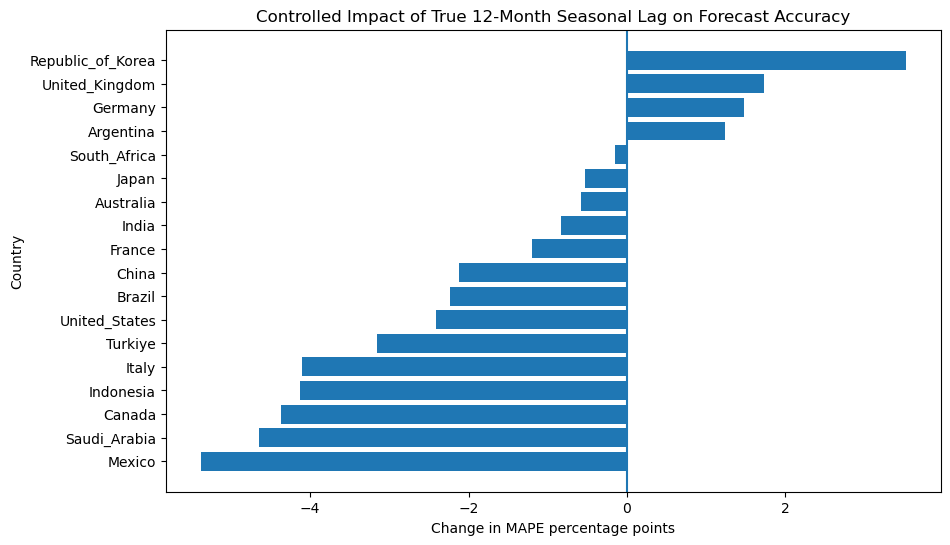

In [143]:
plot_data = controlled_country_comparison.sort_values(
    "MAPE_Change"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Country"],
    plot_data["MAPE_Change"]
)

plt.axvline(0)

plt.xlabel("Change in MAPE percentage points")
plt.ylabel("Country")
plt.title(
    "Controlled Impact of True 12-Month Seasonal Lag on Forecast Accuracy"
)

plt.show()

In [144]:
controlled_country_comparison.round(2).to_csv(
    "controlled_country_comparison.csv",
    index=False
)

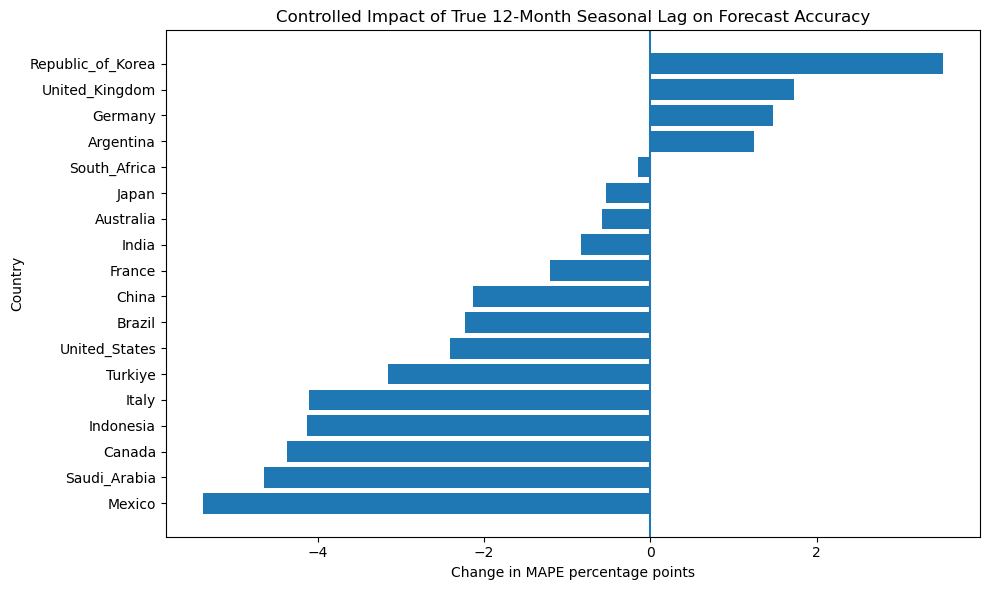

In [145]:
plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Country"],
    plot_data["MAPE_Change"]
)

plt.axvline(0)

plt.xlabel("Change in MAPE percentage points")
plt.ylabel("Country")
plt.title(
    "Controlled Impact of True 12-Month Seasonal Lag on Forecast Accuracy"
)

plt.tight_layout()

plt.savefig(
    "controlled_seasonal_lag_impact.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [146]:
seasonal_feature_importance = pd.Series(
    rf_seasonal.feature_importances_,
    index=X_train_seasonal.columns
).sort_values(ascending=False)

seasonal_feature_importance.head(15)

trade_value_lag12            0.966626
base_metals_index_lag1       0.009522
fed_funds_rate_lag1          0.003096
country_name_South_Africa    0.002192
non_energy_index_lag1        0.001834
usd_broad_index_lag1         0.001610
energy_index_lag1            0.001493
us_cpi_lag1                  0.001436
flowCode_X                   0.001229
fertilizers_index_lag1       0.001218
country_name_India           0.001081
food_index_lag1              0.000791
country_name_Saudi_Arabia    0.000770
us_10y_treasury_rate_lag1    0.000768
crude_oil_avg_usd_lag1       0.000739
dtype: float64

In [147]:
seasonal_feature_importance.drop(
    "trade_value_lag12"
).head(15)

base_metals_index_lag1            0.009522
fed_funds_rate_lag1               0.003096
country_name_South_Africa         0.002192
non_energy_index_lag1             0.001834
usd_broad_index_lag1              0.001610
energy_index_lag1                 0.001493
us_cpi_lag1                       0.001436
flowCode_X                        0.001229
fertilizers_index_lag1            0.001218
country_name_India                0.001081
food_index_lag1                   0.000791
country_name_Saudi_Arabia         0.000770
us_10y_treasury_rate_lag1         0.000768
crude_oil_avg_usd_lag1            0.000739
global_policy_uncertainty_lag1    0.000666
dtype: float64

In [148]:
external_importance = seasonal_feature_importance[
    ~seasonal_feature_importance.index.str.startswith(
        ("country_name_", "flowCode_")
    )
].drop("trade_value_lag12")

external_importance.head(12)

base_metals_index_lag1            0.009522
fed_funds_rate_lag1               0.003096
non_energy_index_lag1             0.001834
usd_broad_index_lag1              0.001610
energy_index_lag1                 0.001493
us_cpi_lag1                       0.001436
fertilizers_index_lag1            0.001218
food_index_lag1                   0.000791
us_10y_treasury_rate_lag1         0.000768
crude_oil_avg_usd_lag1            0.000739
global_policy_uncertainty_lag1    0.000666
precious_metals_index_lag1        0.000627
dtype: float64

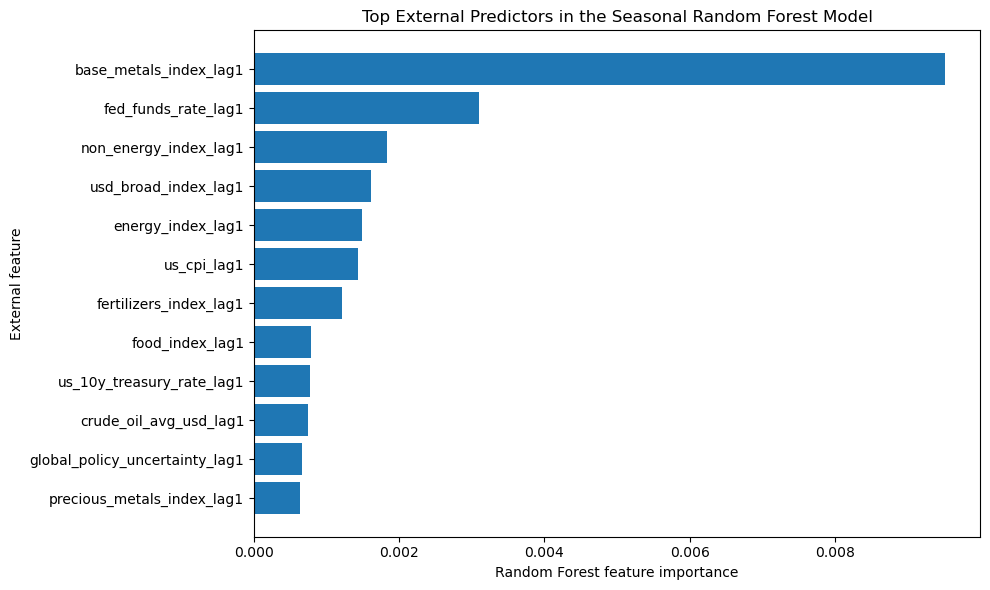

In [149]:
top_external = external_importance.head(12).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_external.index,
    top_external.values
)

plt.xlabel("Random Forest feature importance")
plt.ylabel("External feature")
plt.title("Top External Predictors in the Seasonal Random Forest Model")

plt.tight_layout()
plt.show()

In [150]:
external_feature_columns = [
    column
    for column in X_train_seasonal.columns
    if column.endswith("_lag1")
]

external_feature_columns

['crude_oil_avg_usd_lag1',
 'energy_index_lag1',
 'non_energy_index_lag1',
 'food_index_lag1',
 'fertilizers_index_lag1',
 'base_metals_index_lag1',
 'precious_metals_index_lag1',
 'fed_funds_rate_lag1',
 'usd_broad_index_lag1',
 'us_industrial_production_lag1',
 'us_cpi_lag1',
 'us_10y_treasury_rate_lag1',
 'global_policy_uncertainty_lag1',
 'deep_sea_freight_ppi_lag1']

In [151]:
X_train_seasonal_history = X_train_seasonal.drop(
    columns=external_feature_columns
)

X_test_seasonal_history = X_test_seasonal.drop(
    columns=external_feature_columns
)

print(X_train_seasonal_history.shape)
print(X_test_seasonal_history.shape)

(3764, 22)
(432, 22)


In [152]:
rf_seasonal_history = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_seasonal_history.fit(
    X_train_seasonal_history,
    y_train_seasonal
)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [153]:
seasonal_history_pred_log = rf_seasonal_history.predict(
    X_test_seasonal_history
)

seasonal_history_pred = np.expm1(
    seasonal_history_pred_log
)

In [154]:
seasonal_history_mae = mean_absolute_error(
    seasonal_actual,
    seasonal_history_pred
)

print("Seasonal-history-only MAE:", seasonal_history_mae)

Seasonal-history-only MAE: 3708265260.737863


In [155]:
seasonal_history_rmse = np.sqrt(
    mean_squared_error(
        seasonal_actual,
        seasonal_history_pred
    )
)

print("Seasonal-history-only RMSE:", seasonal_history_rmse)

Seasonal-history-only RMSE: 6201006184.95699


In [156]:
seasonal_history_r2 = r2_score(
    seasonal_actual,
    seasonal_history_pred
)

print("Seasonal-history-only R2:", seasonal_history_r2)

Seasonal-history-only R2: 0.9921999855908742


In [157]:
seasonal_history_mape = (
    abs(
        (seasonal_actual - seasonal_history_pred)
        / seasonal_actual
    ).mean()
    * 100
)

print("Seasonal-history-only MAPE:", seasonal_history_mape)

Seasonal-history-only MAPE: 7.012519424890892


In [158]:
ablation_comparison = pd.DataFrame({
    "Model": [
        "Seasonal history only",
        "Seasonal history plus external indicators"
    ],
    "MAE_USD_bn": [
        seasonal_history_mae / 1_000_000_000,
        seasonal_mae / 1_000_000_000
    ],
    "RMSE_USD_bn": [
        seasonal_history_rmse / 1_000_000_000,
        seasonal_rmse / 1_000_000_000
    ],
    "R2": [
        seasonal_history_r2,
        seasonal_r2
    ],
    "MAPE": [
        seasonal_history_mape,
        seasonal_mape
    ]
})

ablation_comparison.round(3)

,Model,MAE_USD_bn,RMSE_USD_bn,R2,MAPE
0,Seasonal history only,3.708,6.201,0.992,7.013
1,Seasonal history plus external indicators,3.938,6.945,0.990,6.659


In [159]:
seasonal_history_country_results = pd.DataFrame({
    "Country": seasonal_country_results["Country"].values,
    "Actual": np.asarray(seasonal_actual),
    "Predicted": seasonal_history_pred
})

seasonal_history_country_results.head()

,Country,Actual,Predicted
0,Argentina,4.603955e+09,5.261114e+09
1,Argentina,4.118057e+09,5.211962e+09
2,Argentina,4.331571e+09,6.391581e+09
3,Argentina,4.704521e+09,6.432453e+09
4,Argentina,5.012117e+09,6.773466e+09


In [160]:
seasonal_history_country_metrics = []

In [161]:
for country in seasonal_history_country_results["Country"].unique():
    data = seasonal_history_country_results[
        seasonal_history_country_results["Country"] == country
    ]
    
    mae = mean_absolute_error(data["Actual"], data["Predicted"])
    
    rmse = np.sqrt(
        mean_squared_error(data["Actual"], data["Predicted"])
    )
    
    r2 = r2_score(data["Actual"], data["Predicted"])
    
    mape = (
        abs(
            (data["Actual"] - data["Predicted"])
            / data["Actual"]
        ).mean()
        * 100
    )
    
    seasonal_history_country_metrics.append(
        [country, mae, rmse, r2, mape]
    )

seasonal_history_country_metrics[:5]

[['Argentina',
  952386909.2556133,
  np.float64(1153116953.806973),
  -0.3342591689202816,
  np.float64(17.243092367969624)],
 ['Australia',
  1890808642.4443836,
  np.float64(2323534357.6884656),
  -0.24847699155016278,
  np.float64(7.130000983699351)],
 ['Brazil',
  2958834843.4432826,
  np.float64(3616843618.8801274),
  -0.24455657159013788,
  np.float64(11.594103548438872)],
 ['Canada',
  1528896862.6624184,
  np.float64(1874586547.6810677),
  -0.03741361710543378,
  np.float64(3.2576418189584273)],
 ['China',
  10118214026.029873,
  np.float64(13746382618.528324),
  0.9108417550171551,
  np.float64(3.932785803270019)]]

In [162]:
seasonal_history_country_metrics_df = pd.DataFrame(
    seasonal_history_country_metrics,
    columns=["Country", "MAE", "RMSE", "R2", "MAPE"]
)

seasonal_history_country_metrics_df["MAE_USD_bn"] = (
    seasonal_history_country_metrics_df["MAE"] / 1_000_000_000
)

seasonal_history_country_metrics_df["RMSE_USD_bn"] = (
    seasonal_history_country_metrics_df["RMSE"] / 1_000_000_000
)

seasonal_history_country_metrics_display = (
    seasonal_history_country_metrics_df[
        ["Country", "MAE_USD_bn", "RMSE_USD_bn", "R2", "MAPE"]
    ]
)

seasonal_history_country_metrics_display.sort_values(
    "MAPE"
).round(2)

,Country,MAE_USD_bn,RMSE_USD_bn,R2,MAPE
3,Canada,1.53,1.87,-0.04,3.26
4,China,10.12,13.75,0.91,3.93
10,Japan,2.68,3.71,0.10,4.37
9,Italy,2.47,2.99,0.66,4.61
5,France,2.68,3.30,0.71,4.67
17,United_States,12.26,15.71,0.92,5.06
6,Germany,7.22,9.09,0.53,5.48
7,India,3.47,4.31,0.86,6.74
14,South_Africa,0.58,0.70,-0.02,6.79
15,Turkiye,1.74,2.36,0.63,6.80


In [163]:
history_vs_external = (
    seasonal_history_country_metrics_display[
        ["Country", "MAPE", "R2"]
    ]
    .merge(
        corrected_seasonal_country_metrics_display[
            ["Country", "MAPE", "R2"]
        ],
        on="Country",
        suffixes=("_HistoryOnly", "_WithExternal")
    )
)

history_vs_external.head()

,Country,MAPE_HistoryOnly,R2_HistoryOnly,MAPE_WithExternal,R2_WithExternal
0,Argentina,17.243092,-0.334259,16.412206,-0.113736
1,Australia,7.130001,-0.248477,4.988779,0.467245
2,Brazil,11.594104,-0.244557,9.653353,0.072960
3,Canada,3.257642,-0.037414,3.864828,-0.592625
4,China,3.932786,0.910842,4.977314,0.863073


In [164]:
history_vs_external["MAPE_Change"] = (
    history_vs_external["MAPE_WithExternal"]
    - history_vs_external["MAPE_HistoryOnly"]
)

history_vs_external["R2_Change"] = (
    history_vs_external["R2_WithExternal"]
    - history_vs_external["R2_HistoryOnly"]
)

In [165]:
history_vs_external.sort_values(
    "MAPE_Change"
).round(2)

,Country,MAPE_HistoryOnly,R2_HistoryOnly,MAPE_WithExternal,R2_WithExternal,MAPE_Change,R2_Change
13,Saudi_Arabia,8.40,0.53,5.79,0.75,-2.61,0.22
1,Australia,7.13,-0.25,4.99,0.47,-2.14,0.72
2,Brazil,11.59,-0.24,9.65,0.07,-1.94,0.32
15,Turkiye,6.80,0.63,5.19,0.80,-1.61,0.18
8,Indonesia,7.26,0.26,6.01,0.42,-1.26,0.15
14,South_Africa,6.79,-0.02,5.55,0.28,-1.24,0.30
0,Argentina,17.24,-0.33,16.41,-0.11,-0.83,0.22
5,France,4.67,0.71,4.30,0.76,-0.37,0.06
11,Mexico,6.97,-0.44,6.75,-0.58,-0.22,-0.14
17,United_States,5.06,0.92,4.89,0.90,-0.17,-0.01


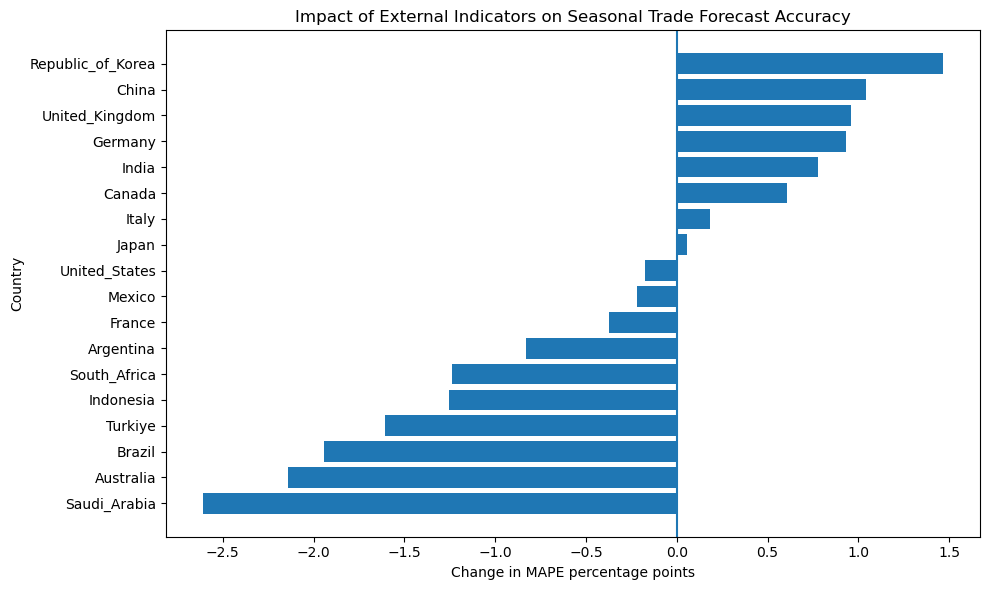

In [166]:
plot_data = history_vs_external.sort_values("MAPE_Change")

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Country"],
    plot_data["MAPE_Change"]
)

plt.axvline(0)

plt.xlabel("Change in MAPE percentage points")
plt.ylabel("Country")
plt.title(
    "Impact of External Indicators on Seasonal Trade Forecast Accuracy"
)

plt.tight_layout()
plt.show()

In [167]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.2.0


In [168]:
from xgboost import XGBRegressor

print("XGBRegressor imported successfully.")

XGBRegressor imported successfully.


In [169]:
print("Training features:", X_train_seasonal.shape)
print("Test features:", X_test_seasonal.shape)

print("Training target:", y_train_seasonal.shape)
print("Test target:", y_test_seasonal.shape)

Training features: (3764, 36)
Test features: (432, 36)
Training target: (3764,)
Test target: (432,)


In [170]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

print("XGBoost model created.")

XGBoost model created.


In [171]:
xgb_model.fit(X_train_seasonal, y_train_seasonal)

print("XGBoost model training completed.")

XGBoost model training completed.


In [172]:
xgb_predictions_log = xgb_model.predict(X_test_seasonal)

print("Predictions created:", len(xgb_predictions_log))

Predictions created: 432


In [173]:
xgb_results_preview = pd.DataFrame({
    "Actual": xgb_actual,
    "Predicted": xgb_predictions
})

xgb_results_preview.head()

NameError: name 'xgb_actual' is not defined

In [174]:
# Convert predictions back from log scale to original USD values

xgb_predictions = np.expm1(xgb_predictions_log)
xgb_actual = np.expm1(y_test_seasonal)

print("Actual values:", len(xgb_actual))
print("Predicted values:", len(xgb_predictions))

Actual values: 432
Predicted values: 432


In [175]:
xgb_results_preview = pd.DataFrame({
    "Actual": np.array(xgb_actual),
    "Predicted": np.array(xgb_predictions)
})

xgb_results_preview.head()

,Actual,Predicted
0,4.603955e+09,4.406828e+09
1,4.118057e+09,4.503157e+09
2,4.331571e+09,6.084409e+09
3,4.704521e+09,5.267837e+09
4,5.012117e+09,6.817530e+09


In [176]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Calculate model performance
xgb_mae = mean_absolute_error(xgb_actual, xgb_predictions)

xgb_rmse = np.sqrt(
    mean_squared_error(xgb_actual, xgb_predictions)
)

xgb_r2 = r2_score(xgb_actual, xgb_predictions)

xgb_mape = np.mean(
    np.abs((xgb_actual - xgb_predictions) / xgb_actual)
) * 100

In [177]:
print("XGBoost Results")
print("----------------")

print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)
print("MAPE:", xgb_mape)

XGBoost Results
----------------
MAE: 4139847679.321683
RMSE: 7239246155.316358
R2: 0.9893694003164142
MAPE: 7.102819039199628


In [178]:
xgb_summary = pd.DataFrame({
    "Model": ["XGBoost"],
    "MAE": [xgb_mae],
    "RMSE": [xgb_rmse],
    "R2": [xgb_r2],
    "MAPE": [xgb_mape]
})

xgb_summary

,Model,MAE,RMSE,R2,MAPE
0,XGBoost,4.139848e+09,7.239246e+09,0.989369,7.102819


In [179]:
xgb_test_results = seasonal_test.copy()

xgb_test_results["Actual"] = xgb_actual
xgb_test_results["Predicted"] = xgb_predictions

xgb_test_results.head()

NameError: name 'seasonal_test' is not defined

In [180]:
xgb_test_results = pd.DataFrame({
    "Actual": np.array(xgb_actual),
    "Predicted": np.array(xgb_predictions)
}, index=X_test_seasonal.index)

xgb_test_results.head()

,Actual,Predicted
119,4.603955e+09,4.406828e+09
120,4.118057e+09,4.503157e+09
121,4.331571e+09,6.084409e+09
122,4.704521e+09,5.267837e+09
123,5.012117e+09,6.817530e+09


In [181]:
xgb_test_results["Absolute_Error"] = np.abs(
    xgb_test_results["Actual"] - xgb_test_results["Predicted"]
)

xgb_test_results["Percentage_Error"] = (
    xgb_test_results["Absolute_Error"]
    / xgb_test_results["Actual"]
) * 100

xgb_test_results.head()

,Actual,Predicted,Absolute_Error,Percentage_Error
119,4.603955e+09,4.406828e+09,1.971271e+08,4.281691
120,4.118057e+09,4.503157e+09,3.850993e+08,9.351480
121,4.331571e+09,6.084409e+09,1.752839e+09,40.466580
122,4.704521e+09,5.267837e+09,5.633161e+08,11.973929
123,5.012117e+09,6.817530e+09,1.805413e+09,36.020963


In [182]:
xgb_test_results["Country"] = seasonal_model_df.loc[
    seasonal_test_df.index,
    "country_name"
].values

In [183]:
xgb_test_results = xgb_test_results[
    [
        "Country",
        "Actual",
        "Predicted",
        "Absolute_Error",
        "Percentage_Error"
    ]
]

xgb_test_results.head()

,Country,Actual,Predicted,Absolute_Error,Percentage_Error
119,Argentina,4.603955e+09,4.406828e+09,1.971271e+08,4.281691
120,Argentina,4.118057e+09,4.503157e+09,3.850993e+08,9.351480
121,Argentina,4.331571e+09,6.084409e+09,1.752839e+09,40.466580
122,Argentina,4.704521e+09,5.267837e+09,5.633161e+08,11.973929
123,Argentina,5.012117e+09,6.817530e+09,1.805413e+09,36.020963


In [184]:
xgb_test_results["Country"].value_counts()

Country
Argentina            24
Australia            24
United_Kingdom       24
Turkiye              24
South_Africa         24
Saudi_Arabia         24
Republic_of_Korea    24
Mexico               24
Japan                24
Italy                24
Indonesia            24
India                24
Germany              24
France               24
China                24
Canada               24
Brazil               24
United_States        24
Name: count, dtype: int64

In [185]:
country_results = []

for country in xgb_test_results["Country"].unique():

    country_data = xgb_test_results[
        xgb_test_results["Country"] == country
    ]

    country_mae = mean_absolute_error(
        country_data["Actual"],
        country_data["Predicted"]
    )

    country_rmse = np.sqrt(
        mean_squared_error(
            country_data["Actual"],
            country_data["Predicted"]
        )
    )

    country_r2 = r2_score(
        country_data["Actual"],
        country_data["Predicted"]
    )

    country_mape = country_data["Percentage_Error"].mean()

    country_results.append({
        "Country": country,
        "MAE": country_mae,
        "RMSE": country_rmse,
        "R2": country_r2,
        "MAPE": country_mape
    })

In [186]:
xgb_country_metrics = pd.DataFrame(country_results)

xgb_country_metrics = xgb_country_metrics.sort_values(
    by="MAPE"
).reset_index(drop=True)

xgb_country_metrics

,Country,MAE,RMSE,R2,MAPE
0,Canada,2.087140e+09,2.498866e+09,-0.843430,4.449320
1,United_States,1.135293e+10,1.608986e+10,0.914298,4.567403
2,Italy,2.738464e+09,3.367462e+09,0.566390,5.007022
3,Japan,3.071090e+09,3.561043e+09,0.170158,5.025115
4,China,1.373608e+10,1.727556e+10,0.859185,5.170961
5,France,3.056807e+09,5.084144e+09,0.304357,5.286785
6,Australia,1.569765e+09,1.930786e+09,0.137914,5.959477
7,South_Africa,5.389704e+08,6.608919e+08,0.083138,6.102955
8,Turkiye,1.575347e+09,2.080231e+09,0.711150,6.209013
9,Mexico,3.342148e+09,4.116526e+09,-0.294693,6.269920


In [187]:
xgb_country_metrics["MAE_Billion"] = (
    xgb_country_metrics["MAE"] / 1_000_000_000
)

xgb_country_metrics["RMSE_Billion"] = (
    xgb_country_metrics["RMSE"] / 1_000_000_000
)

xgb_country_metrics[
    [
        "Country",
        "MAE_Billion",
        "RMSE_Billion",
        "R2",
        "MAPE"
    ]
].round(2)

,Country,MAE_Billion,RMSE_Billion,R2,MAPE
0,Canada,2.09,2.50,-0.84,4.45
1,United_States,11.35,16.09,0.91,4.57
2,Italy,2.74,3.37,0.57,5.01
3,Japan,3.07,3.56,0.17,5.03
4,China,13.74,17.28,0.86,5.17
5,France,3.06,5.08,0.30,5.29
6,Australia,1.57,1.93,0.14,5.96
7,South_Africa,0.54,0.66,0.08,6.10
8,Turkiye,1.58,2.08,0.71,6.21
9,Mexico,3.34,4.12,-0.29,6.27


In [188]:
xgb_country_results_final = xgb_country_metrics[
    [
        "Country",
        "MAE_Billion",
        "RMSE_Billion",
        "R2",
        "MAPE"
    ]
].copy()

xgb_country_results_final = xgb_country_results_final.round({
    "MAE_Billion": 2,
    "RMSE_Billion": 2,
    "R2": 2,
    "MAPE": 2
})

xgb_country_results_final

,Country,MAE_Billion,RMSE_Billion,R2,MAPE
0,Canada,2.09,2.50,-0.84,4.45
1,United_States,11.35,16.09,0.91,4.57
2,Italy,2.74,3.37,0.57,5.01
3,Japan,3.07,3.56,0.17,5.03
4,China,13.74,17.28,0.86,5.17
5,France,3.06,5.08,0.30,5.29
6,Australia,1.57,1.93,0.14,5.96
7,South_Africa,0.54,0.66,0.08,6.10
8,Turkiye,1.58,2.08,0.71,6.21
9,Mexico,3.34,4.12,-0.29,6.27


In [189]:
xgb_country_results_final.columns = [
    "Country",
    "MAE_USD_Billion",
    "RMSE_USD_Billion",
    "R2",
    "MAPE_Percent"
]

xgb_country_results_final

,Country,MAE_USD_Billion,RMSE_USD_Billion,R2,MAPE_Percent
0,Canada,2.09,2.50,-0.84,4.45
1,United_States,11.35,16.09,0.91,4.57
2,Italy,2.74,3.37,0.57,5.01
3,Japan,3.07,3.56,0.17,5.03
4,China,13.74,17.28,0.86,5.17
5,France,3.06,5.08,0.30,5.29
6,Australia,1.57,1.93,0.14,5.96
7,South_Africa,0.54,0.66,0.08,6.10
8,Turkiye,1.58,2.08,0.71,6.21
9,Mexico,3.34,4.12,-0.29,6.27


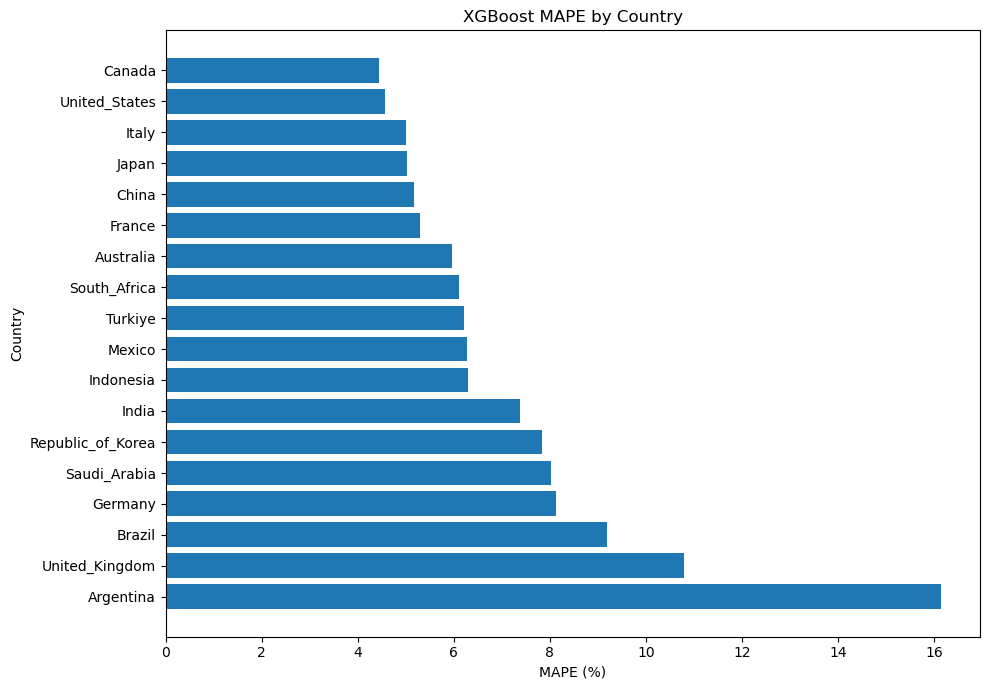

In [190]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.barh(
    xgb_country_results_final["Country"],
    xgb_country_results_final["MAPE_Percent"]
)

plt.xlabel("MAPE (%)")
plt.ylabel("Country")
plt.title("XGBoost MAPE by Country")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [191]:
xgb_country_results_final.to_csv(
    "xgboost_country_results.csv",
    index=False
)

print("XGBoost country results saved.")

XGBoost country results saved.


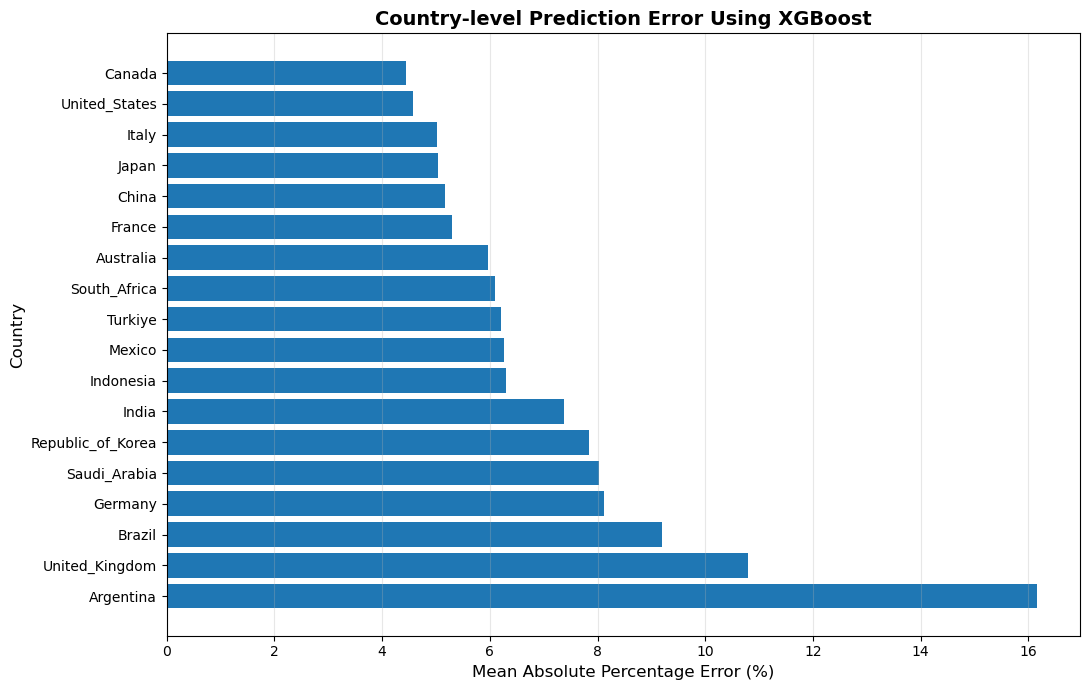

In [192]:
plt.figure(figsize=(11,7))

plt.barh(
    xgb_country_results_final["Country"],
    xgb_country_results_final["MAPE_Percent"]
)

plt.xlabel("Mean Absolute Percentage Error (%)", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.title("Country-level Prediction Error Using XGBoost", fontsize=14, weight="bold")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [193]:
tree_results = []

tree_values = [100, 300, 500]

for trees in tree_values:

    model = XGBRegressor(
        n_estimators=trees,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )

    model.fit(X_train_seasonal, y_train_seasonal)

    predictions = model.predict(X_test_seasonal)

    predictions = np.expm1(predictions)

    actual = np.expm1(y_test_seasonal)

    mape = np.mean(
        np.abs((actual - predictions) / actual)
    ) * 100

    tree_results.append({
        "Number of Trees": trees,
        "MAPE": mape
    })

tree_results = pd.DataFrame(tree_results)

tree_results

,Number of Trees,MAPE
0,100,7.240501
1,300,7.102819
2,500,7.079220


In [194]:
depth_results = []

depth_values = [3, 4, 5, 6]

for depth in depth_values:

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train_seasonal, y_train_seasonal)

    predictions_log = model.predict(X_test_seasonal)

    predictions = np.expm1(predictions_log)
    actual = np.expm1(y_test_seasonal)

    mape = np.mean(
        np.abs((actual - predictions) / actual)
    ) * 100

    depth_results.append({
        "Maximum Depth": depth,
        "MAPE": mape
    })

depth_results = pd.DataFrame(depth_results)

depth_results

,Maximum Depth,MAPE
0,3,7.759992
1,4,7.102819
2,5,7.128601
3,6,7.543881


In [195]:
learning_rate_results = []

In [196]:
learning_rate_values = [0.01, 0.05, 0.10]

In [197]:
for rate in learning_rate_values:

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=rate,
        max_depth=4,
        random_state=42
    )

In [198]:
    model.fit(
        X_train_seasonal,
        y_train_seasonal
    )

    predictions_log = model.predict(X_test_seasonal)

In [199]:
    predictions = np.expm1(predictions_log)
    actual = np.expm1(y_test_seasonal)

    mape = np.mean(
        np.abs((actual - predictions) / actual)
    ) * 100

In [200]:
    learning_rate_results.append({
        "Learning Rate": rate,
        "MAPE": mape
    })

In [201]:
learning_rate_results = pd.DataFrame(
    learning_rate_results
)

learning_rate_results

,Learning Rate,MAPE
0,0.1,7.128297


In [202]:
learning_rate_results = []

for rate in [0.01, 0.05, 0.10]:
    model = XGBRegressor(n_estimators=300, learning_rate=rate, max_depth=4, random_state=42)
    model.fit(X_train_seasonal, y_train_seasonal)
    predictions = np.expm1(model.predict(X_test_seasonal))
    learning_rate_results.append([rate, np.mean(np.abs((xgb_actual - predictions) / xgb_actual)) * 100])

In [203]:
learning_rate_results = pd.DataFrame(
    learning_rate_results,
    columns=["Learning Rate", "MAPE"]
)

learning_rate_results

,Learning Rate,MAPE
0,0.01,8.530082
1,0.05,7.102819
2,0.10,7.128297


In [204]:
final_xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

In [205]:
final_xgb_model.fit(
    X_train_seasonal,
    y_train_seasonal
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [206]:
final_xgb_predictions_log = final_xgb_model.predict(
    X_test_seasonal
)

In [207]:
final_xgb_predictions = np.expm1(
    final_xgb_predictions_log
)

final_xgb_actual = np.expm1(
    y_test_seasonal
)

In [208]:
final_xgb_mae = mean_absolute_error(
    final_xgb_actual,
    final_xgb_predictions
)

final_xgb_rmse = np.sqrt(
    mean_squared_error(final_xgb_actual, final_xgb_predictions)
)

In [209]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [210]:
final_xgb_mae = mean_absolute_error(
    final_xgb_actual,
    final_xgb_predictions
)

final_xgb_rmse = np.sqrt(
    mean_squared_error(
        final_xgb_actual,
        final_xgb_predictions
    )
)

In [211]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error, r2_score

In [212]:
final_xgb_model = XGBRegressor(
    n_estimators=300, max_depth=4,
    learning_rate=0.05, random_state=42
)

final_xgb_model.fit(X_train_seasonal, y_train_seasonal)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [213]:
seasonal_model_df_encoded

,period,date,year,month,quarter,flowDesc,primaryValue,crude_oil_avg_usd_lag1,energy_index_lag1,non_energy_index_lag1,...,country_name_Italy,country_name_Japan,country_name_Mexico,country_name_Republic_of_Korea,country_name_Saudi_Arabia,country_name_South_Africa,country_name_Turkiye,country_name_United_Kingdom,country_name_United_States,flowCode_X
12,201502,2015-02-01,2015,2,1,Import,3.990543e+09,47.1067,63.7491,87.6837,...,False,False,False,False,False,False,False,False,False,False
13,201503,2015-03-01,2015,3,1,Import,5.054646e+09,54.7900,73.7662,86.1377,...,False,False,False,False,False,False,False,False,False,False
14,201504,2015-04-01,2015,4,2,Import,4.952791e+09,52.8267,71.1451,84.5029,...,False,False,False,False,False,False,False,False,False,False
15,201505,2015-05-01,2015,5,2,Import,4.991700e+09,57.5433,73.3589,84.1862,...,False,False,False,False,False,False,False,False,False,False
16,201506,2015-06-01,2015,6,2,Import,5.759709e+09,62.5067,79.2574,84.8712,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4631,202408,2024-08-01,2024,8,3,Export,1.803749e+11,83.2587,105.9796,111.7083,...,False,False,False,False,False,False,False,False,True,True
4632,202409,2024-09-01,2024,9,3,Export,1.713956e+11,78.1210,102.6462,109.6065,...,False,False,False,False,False,False,False,False,True,True
4633,202410,2024-10-01,2024,10,4,Export,1.767911e+11,72.4243,95.3732,112.1884,...,False,False,False,False,False,False,False,False,True,True
4634,202411,2024-11-01,2024,11,4,Export,1.742786e+11,73.9707,97.6707,114.5548,...,False,False,False,False,False,False,False,False,True,True


In [214]:
seasonal_train_df = seasonal_model_df_encoded[
    seasonal_model_df_encoded["year"] <= 2023
]

seasonal_test_df = seasonal_model_df_encoded[
    seasonal_model_df_encoded["year"] == 2024
]

In [215]:
print("Training rows:", len(seasonal_train_df))
print("Test rows:", len(seasonal_test_df))

Training rows: 3764
Test rows: 432


In [216]:
drop_columns = [
    "primaryValue",
    "date",
    "period",
    "flowDesc",
    "year"
]

In [217]:
X_train_seasonal = seasonal_train_df.drop(
    columns=drop_columns + ["log_primaryValue"]
)

X_test_seasonal = seasonal_test_df.drop(
    columns=drop_columns + ["log_primaryValue"]
)

In [218]:
y_train_seasonal = seasonal_train_df[
    "log_primaryValue"
]

y_test_seasonal = seasonal_test_df[
    "log_primaryValue"
]

In [219]:
print("Training features:", X_train_seasonal.shape)
print("Test features:", X_test_seasonal.shape)

print("Training target:", y_train_seasonal.shape)
print("Test target:", y_test_seasonal.shape)

Training features: (3764, 35)
Test features: (432, 35)
Training target: (3764,)
Test target: (432,)


In [220]:
final_xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

In [221]:
final_xgb_model.fit(
    X_train_seasonal,
    y_train_seasonal
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [222]:
final_xgb_predictions_log = final_xgb_model.predict(
    X_test_seasonal
)

In [223]:
final_xgb_predictions = np.expm1(
    final_xgb_predictions_log
)

final_xgb_actual = np.expm1(
    y_test_seasonal
)

In [224]:
final_xgb_mae = mean_absolute_error(
    final_xgb_actual, final_xgb_predictions
)

final_xgb_rmse = np.sqrt(
    mean_squared_error(final_xgb_actual, final_xgb_predictions)
)

In [225]:
final_xgb_r2 = r2_score(
    final_xgb_actual, final_xgb_predictions
)

final_xgb_mape = np.mean(
    np.abs((final_xgb_actual - final_xgb_predictions) / final_xgb_actual)
) * 100

In [226]:
print("Final XGBoost Results")
print("---------------------")
print("MAE:", round(final_xgb_mae / 1e9, 2), "billion USD")
print("RMSE:", round(final_xgb_rmse / 1e9, 2), "billion USD")
print("R2:", round(final_xgb_r2, 4))
print("MAPE:", round(final_xgb_mape, 2), "%")

Final XGBoost Results
---------------------
MAE: 4.17 billion USD
RMSE: 7.42 billion USD
R2: 0.9888
MAPE: 7.06 %


In [227]:
final_xgb_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "MAE (USD bn)": [final_xgb_mae / 1e9],
    "RMSE (USD bn)": [final_xgb_rmse / 1e9],
    "R2": [final_xgb_r2],
    "MAPE (%)": [final_xgb_mape]
})

In [228]:
final_xgb_results.round(3)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,XGBoost,4.165,7.42,0.989,7.057


In [229]:
from sklearn.ensemble import HistGradientBoostingRegressor

In [230]:
hgb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

In [231]:
hgb_model.fit(
    X_train_seasonal,
    y_train_seasonal
)

,loss,'squared_error'
,quantile,None
,learning_rate,0.05
,max_iter,300
,max_leaf_nodes,31
,max_depth,4
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'


In [232]:
hgb_predictions_log = hgb_model.predict(
    X_test_seasonal
)

In [233]:
hgb_predictions = np.expm1(
    hgb_predictions_log
)

hgb_actual = np.expm1(
    y_test_seasonal
)

In [234]:
hgb_mae = mean_absolute_error(
    hgb_actual, hgb_predictions
)

hgb_rmse = np.sqrt(
    mean_squared_error(hgb_actual, hgb_predictions)
)

In [235]:
hgb_r2 = r2_score(
    hgb_actual, hgb_predictions
)

hgb_mape = np.mean(
    np.abs((hgb_actual - hgb_predictions) / hgb_actual)
) * 100

In [236]:
print("HistGradientBoosting Results")
print("----------------------------")
print("MAE:", round(hgb_mae / 1e9, 2), "billion USD")
print("RMSE:", round(hgb_rmse / 1e9, 2), "billion USD")
print("R2:", round(hgb_r2, 4))
print("MAPE:", round(hgb_mape, 2), "%")

HistGradientBoosting Results
----------------------------
MAE: 4.08 billion USD
RMSE: 7.0 billion USD
R2: 0.9901
MAPE: 7.22 %


In [237]:
hgb_results = pd.DataFrame({
    "Model": ["HistGradientBoosting"],
    "MAE (USD bn)": [hgb_mae / 1e9],
    "RMSE (USD bn)": [hgb_rmse / 1e9],
    "R2": [hgb_r2],
    "MAPE (%)": [hgb_mape]
})

In [238]:
hgb_results.round(3)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,HistGradientBoosting,4.084,7.0,0.99,7.219


In [239]:
model_comparison = pd.concat([
    lr_results,
    rf_results,
    svr_results,
    final_xgb_results,
    hgb_results
], ignore_index=True)

In [240]:
model_comparison.round(3)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Linear Regression,10.231,19.727,0.921,13.619
1,Random Forest,5.021,8.942,0.984,8.277
2,SVR,13.317,18.045,0.934,33.717
3,XGBoost,4.165,7.420,0.989,7.057
4,HistGradientBoosting,4.084,7.000,0.990,7.219


In [241]:
seasonal_rf_results = pd.DataFrame({
    "Model": ["Seasonal Random Forest"],
    "MAE (USD bn)": [3.94],
    "RMSE (USD bn)": [6.95],
    "R2": [0.9902],
    "MAPE (%)": [6.66]
})

In [242]:
model_comparison = pd.concat([
    lr_results, rf_results, seasonal_rf_results,
    svr_results, final_xgb_results, hgb_results
], ignore_index=True)

In [243]:
model_comparison.round(3)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Linear Regression,10.231,19.727,0.921,13.619
1,Random Forest,5.021,8.942,0.984,8.277
2,Seasonal Random Forest,3.940,6.950,0.990,6.660
3,SVR,13.317,18.045,0.934,33.717
4,XGBoost,4.165,7.420,0.989,7.057
5,HistGradientBoosting,4.084,7.000,0.990,7.219


In [244]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Seasonal Random Forest",
              "SVR", "XGBoost", "HistGradientBoosting", "LSTM"],
    "MAE (USD bn)": [10.231, 5.021, 3.940, 13.317, 4.165, 4.084, 19.852],
    "RMSE (USD bn)": [19.727, 8.942, 6.950, 18.045, 7.420, 7.000, 42.689],
    "R2": [0.921, 0.984, 0.990, 0.934, 0.989, 0.990, 0.630],
    "MAPE (%)": [13.619, 8.277, 6.660, 33.717, 7.057, 7.219, 27.343]
})

In [245]:
model_comparison.round(3)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Linear Regression,10.231,19.727,0.921,13.619
1,Random Forest,5.021,8.942,0.984,8.277
2,Seasonal Random Forest,3.940,6.950,0.990,6.660
3,SVR,13.317,18.045,0.934,33.717
4,XGBoost,4.165,7.420,0.989,7.057
5,HistGradientBoosting,4.084,7.000,0.990,7.219
6,LSTM,19.852,42.689,0.630,27.343


In [246]:
[name for name in globals()
 if "season" in name.lower()
 or "pred" in name.lower()]

['y_pred_log',
 'y_pred',
 'rf_pred_log',
 'rf_pred',
 'svr_pred_log',
 'svr_pred',
 'rf_baseline_predictions',
 'seasonal_model_df',
 'seasonal_model_df_encoded',
 'seasonal_train_df',
 'seasonal_test_df',
 'seasonal_drop_cols',
 'X_train_seasonal',
 'y_train_seasonal',
 'X_test_seasonal',
 'y_test_seasonal',
 'rf_seasonal',
 'seasonal_pred_log',
 'seasonal_pred',
 'seasonal_actual',
 'seasonal_mae',
 'seasonal_rmse',
 'seasonal_r2',
 'seasonal_mape',
 'seasonal_country_results',
 'seasonal_country_metrics',
 'seasonal_country_metrics_df',
 'seasonal_country_metrics_display',
 'corrected_seasonal_country_metrics',
 'corrected_seasonal_country_metrics_df',
 'corrected_seasonal_country_metrics_display',
 'matched_external_pred_log',
 'matched_external_pred',
 'seasonal_feature_importance',
 'X_train_seasonal_history',
 'X_test_seasonal_history',
 'rf_seasonal_history',
 'seasonal_history_pred_log',
 'seasonal_history_pred',
 'seasonal_history_mae',
 'seasonal_history_rmse',
 'seasonal_h

In [247]:
error_analysis = seasonal_test_df[
    ["date", "country_name", "flowCode"]
].copy()

KeyError: "['country_name', 'flowCode'] not in index"

In [248]:
seasonal_test_labels = seasonal_model_df.loc[
    seasonal_test_df.index,
    ["date", "country_name", "flowCode"]
].copy()

In [249]:
error_analysis = seasonal_test_labels.copy()

error_analysis["Actual"] = np.array(seasonal_actual)
error_analysis["Predicted"] = np.array(seasonal_pred)

In [250]:
error_analysis["Residual"] = (
    error_analysis["Actual"]
    - error_analysis["Predicted"]
)

error_analysis.head()

,date,country_name,flowCode,Actual,Predicted,Residual
119,2024-01-01,Argentina,M,4.603955e+09,5.201057e+09,-5.971023e+08
120,2024-02-01,Argentina,M,4.118057e+09,4.970995e+09,-8.529372e+08
121,2024-03-01,Argentina,M,4.331571e+09,5.997760e+09,-1.666189e+09
122,2024-04-01,Argentina,M,4.704521e+09,5.770657e+09,-1.066136e+09
123,2024-05-01,Argentina,M,5.012117e+09,6.521666e+09,-1.509549e+09


In [251]:
country_error_summary = error_analysis.groupby(
    "country_name"
)["Residual"].agg(
    Mean_Error="mean",
    Median_Error="median",
    Maximum_Underprediction="max",
    Maximum_Overprediction="min",
    Error_Standard_Deviation="std"
).reset_index()

In [253]:
error_columns = country_error_summary.columns[1:]

country_error_summary[error_columns] = (
    country_error_summary[error_columns] / 1_000_000_000
)

In [254]:
country_error_summary.round(3)

,country_name,Mean_Error,Median_Error,Maximum_Underprediction,Maximum_Overprediction,Error_Standard_Deviation
0,Argentina,-0.0,0.0,0.0,-0.0,0.0
1,Australia,0.0,0.0,0.0,-0.0,0.0
2,Brazil,0.0,0.0,0.0,-0.0,0.0
3,Canada,0.0,0.0,0.0,-0.0,0.0
4,China,0.0,0.0,0.0,-0.0,0.0
5,France,0.0,0.0,0.0,-0.0,0.0
6,Germany,-0.0,0.0,0.0,-0.0,0.0
7,India,0.0,0.0,0.0,-0.0,0.0
8,Indonesia,0.0,0.0,0.0,-0.0,0.0
9,Italy,0.0,0.0,0.0,-0.0,0.0


In [255]:
country_error_summary = error_analysis.groupby(
    "country_name"
)["Residual"].agg(
    Mean_Error="mean",
    Median_Error="median",
    Maximum_Underprediction="max",
    Maximum_Overprediction="min",
    Error_Standard_Deviation="std"
).reset_index()

In [256]:
country_error_summary_bn = country_error_summary.copy()

error_cols = country_error_summary_bn.columns[1:]
country_error_summary_bn[error_cols] = (
    country_error_summary_bn[error_cols] / 1_000_000_000
)

In [257]:
country_error_summary_bn.round(2)

,country_name,Mean_Error,Median_Error,Maximum_Underprediction,Maximum_Overprediction,Error_Standard_Deviation
0,Argentina,-0.06,0.24,1.80,-2.15,1.07
1,Australia,0.32,0.25,3.10,-1.83,1.51
2,Brazil,1.91,1.78,5.89,-2.94,2.52
3,Canada,1.69,1.64,4.83,-0.66,1.63
4,China,9.86,9.10,48.18,-21.18,14.19
5,France,0.39,0.62,5.26,-4.94,2.99
6,Germany,-0.21,1.71,17.19,-22.80,10.45
7,India,3.51,2.95,10.80,-2.46,3.40
8,Indonesia,0.70,0.73,3.15,-1.94,1.44
9,Italy,0.98,0.43,7.17,-4.78,3.22


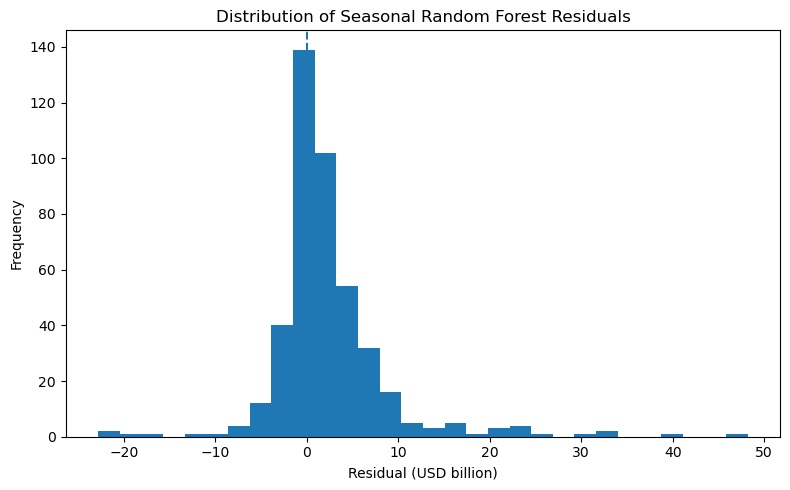

In [258]:
plt.figure(figsize=(8, 5))

plt.hist(
    error_analysis["Residual"] / 1e9,
    bins=30
)

plt.axvline(0, linestyle="--")
plt.xlabel("Residual (USD billion)")
plt.ylabel("Frequency")
plt.title("Distribution of Seasonal Random Forest Residuals")
plt.tight_layout()
plt.show()

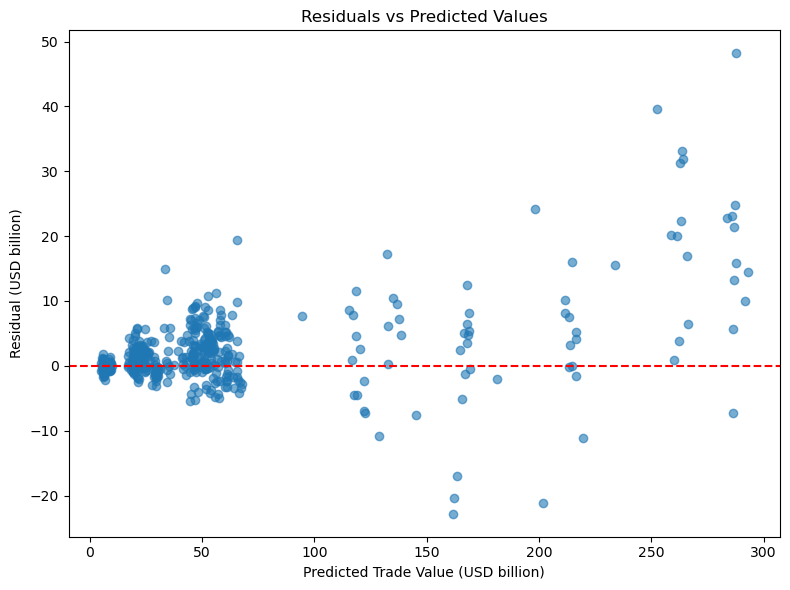

In [259]:
plt.figure(figsize=(8,6))

plt.scatter(
    error_analysis["Predicted"] / 1e9,
    error_analysis["Residual"] / 1e9,
    alpha=0.6
)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Trade Value (USD billion)")
plt.ylabel("Residual (USD billion)")
plt.title("Residuals vs Predicted Values")

plt.tight_layout()
plt.show()

In [261]:
monthly_residuals = (
    error_analysis
    .groupby("date")["Residual"]
    .mean()
    / 1e9
)

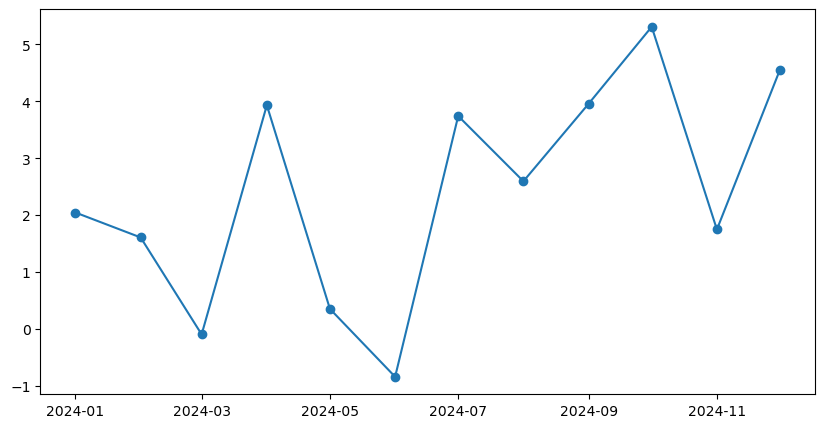

In [262]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_residuals.index,
    monthly_residuals.values,
    marker="o"
)

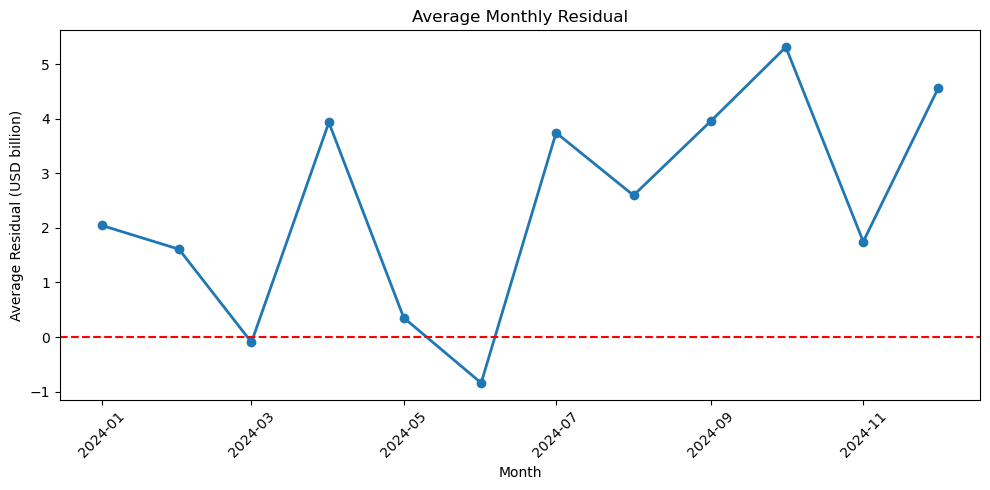

In [264]:
monthly_residuals = (
    error_analysis
    .groupby("date")["Residual"]
    .mean()
    / 1e9
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_residuals.index,
    monthly_residuals.values,
    marker="o",
    linewidth=2
)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Month")
plt.ylabel("Average Residual (USD billion)")
plt.title("Average Monthly Residual")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [265]:
import shap

print("SHAP version:", shap.__version__)

ModuleNotFoundError: No module named 'shap'

In [266]:
import sys
print(sys.executable)

/opt/anaconda3/bin/python


In [267]:
import sys

!{sys.executable} -m pip install shap

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]━━━━━━ 1/2 [shap]


In [268]:
import importlib
importlib.invalidate_caches()

import shap
print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [269]:
# Recovering the feature columns used to train the Seasonal Random Forest
rf_feature_names = list(rf_seasonal.feature_names_in_)

# Selecting those columns from the 2024 test data
X_shap = seasonal_test_df[rf_feature_names].copy()

print("Features expected by model:", rf_seasonal.n_features_in_)
print("Features supplied to SHAP:", X_shap.shape[1])
print("Test rows:", X_shap.shape[0])

Features expected by model: 36
Features supplied to SHAP: 36
Test rows: 432


In [271]:
# Using a sample to keep SHAP processing manageable
X_shap_sample = X_shap.sample(
    n=min(300, len(X_shap)),
    random_state=42
)

# Create the SHAP explainer
explainer = shap.TreeExplainer(rf_seasonal)

# Calculate SHAP values
shap_values = explainer(X_shap_sample)

print("SHAP values calculated successfully")
print("SHAP values shape:", shap_values.values.shape)

SHAP values calculated successfully
SHAP values shape: (300, 36)


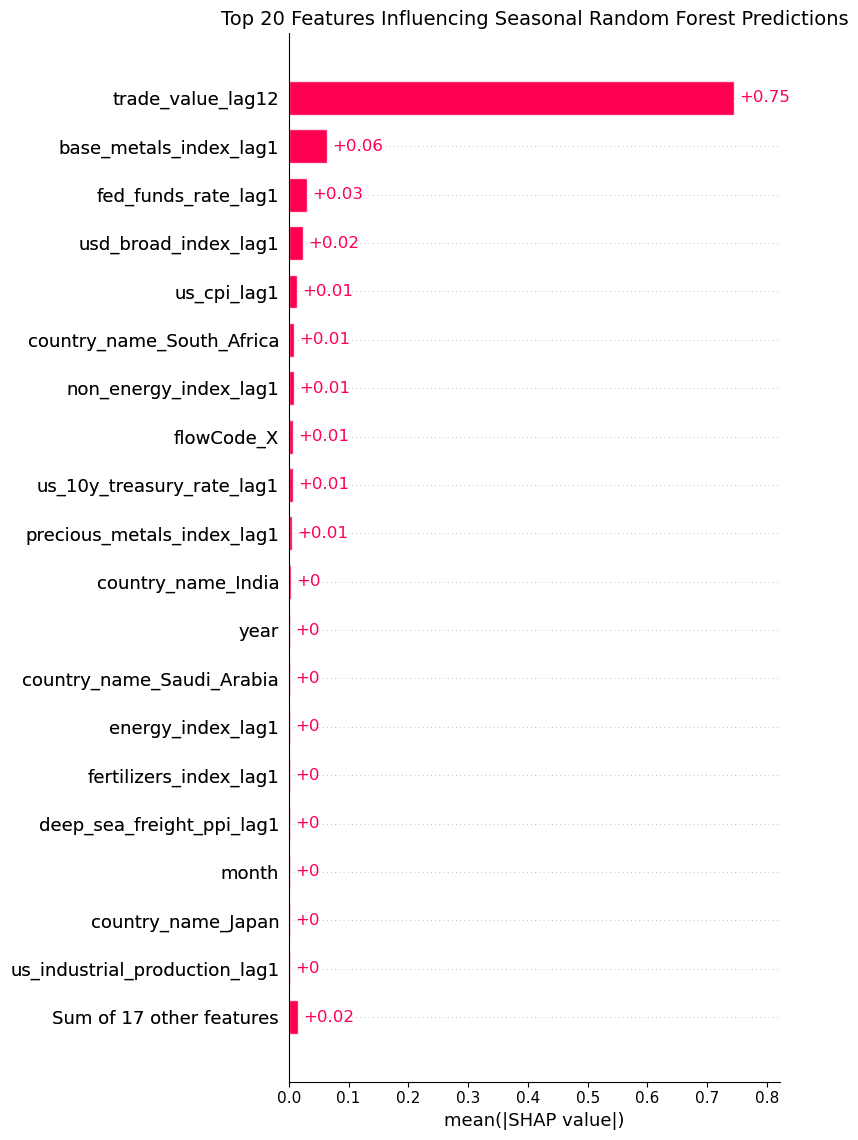

In [272]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

shap.plots.bar(
    shap_values,
    max_display=20,
    show=False
)

plt.title(
    "Top 20 Features Influencing Seasonal Random Forest Predictions",
    fontsize=14
)

plt.tight_layout()
plt.show()

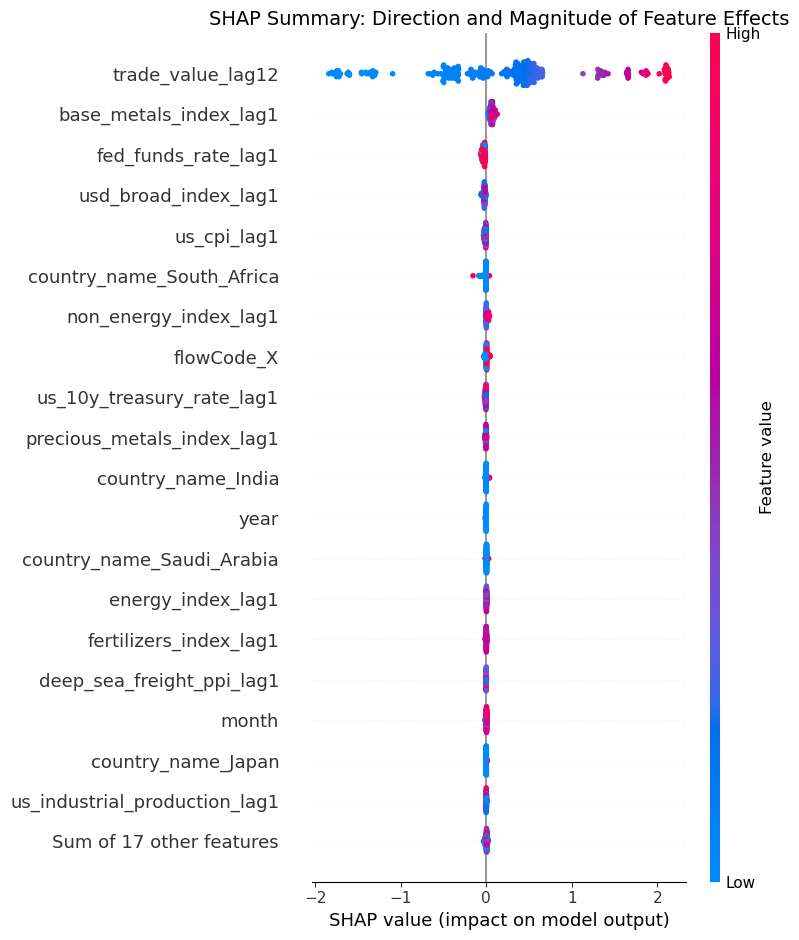

In [273]:
plt.figure(figsize=(11, 8))

shap.plots.beeswarm(
    shap_values,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Summary: Direction and Magnitude of Feature Effects",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [275]:
# Calculating numerical SHAP importance for every feature
shap_importance = pd.DataFrame({
    "Feature": X_shap_sample.columns,
    "Mean_Absolute_SHAP": np.abs(shap_values.values).mean(axis=0)
}).sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

# Keep only lagged external indicators
external_shap_importance = shap_importance[
    shap_importance["Feature"].str.endswith("_lag1")
].copy()

external_shap_importance.round(4)

,Feature,Mean_Absolute_SHAP
8,base_metals_index_lag1,0.0646
10,fed_funds_rate_lag1,0.0311
11,usd_broad_index_lag1,0.0230
13,us_cpi_lag1,0.0139
5,non_energy_index_lag1,0.0083
14,us_10y_treasury_rate_lag1,0.0064
9,precious_metals_index_lag1,0.0053
4,energy_index_lag1,0.0025
7,fertilizers_index_lag1,0.0024
16,deep_sea_freight_ppi_lag1,0.0022


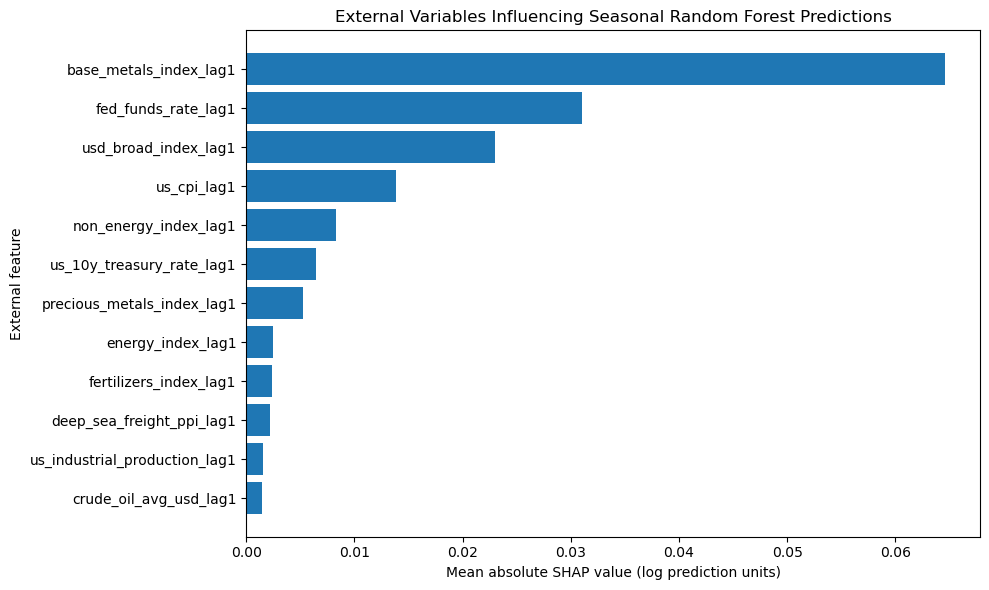

In [276]:
top_external_shap = (
    external_shap_importance
    .head(12)
    .sort_values("Mean_Absolute_SHAP")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_external_shap["Feature"],
    top_external_shap["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean absolute SHAP value (log prediction units)")
plt.ylabel("External feature")
plt.title(
    "External Variables Influencing Seasonal Random Forest Predictions"
)

plt.tight_layout()

plt.savefig(
    "shap_external_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

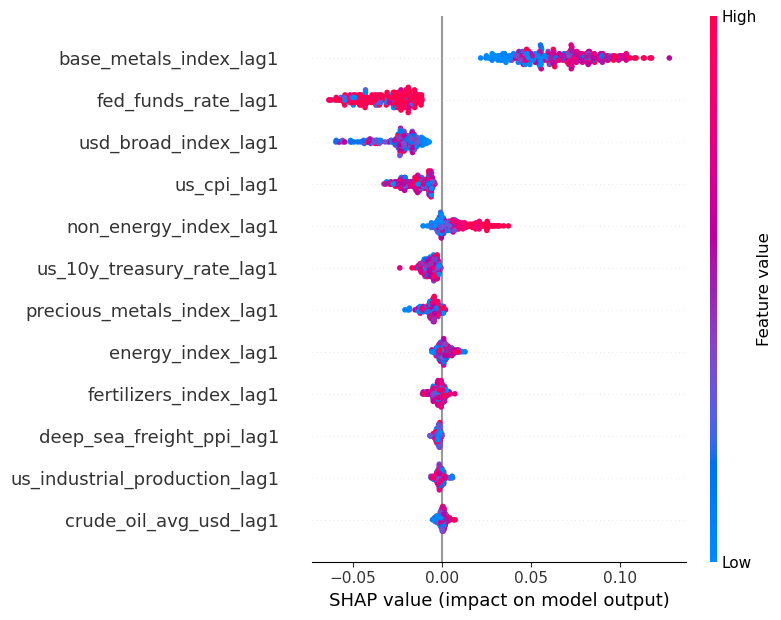

In [277]:
external_cols = [c for c in X_shap_sample.columns if c.endswith("_lag1")]
external_idx = [X_shap_sample.columns.get_loc(c) for c in external_cols]

shap.summary_plot(
    shap_values.values[:, external_idx],
    X_shap_sample[external_cols],
    max_display=12
)

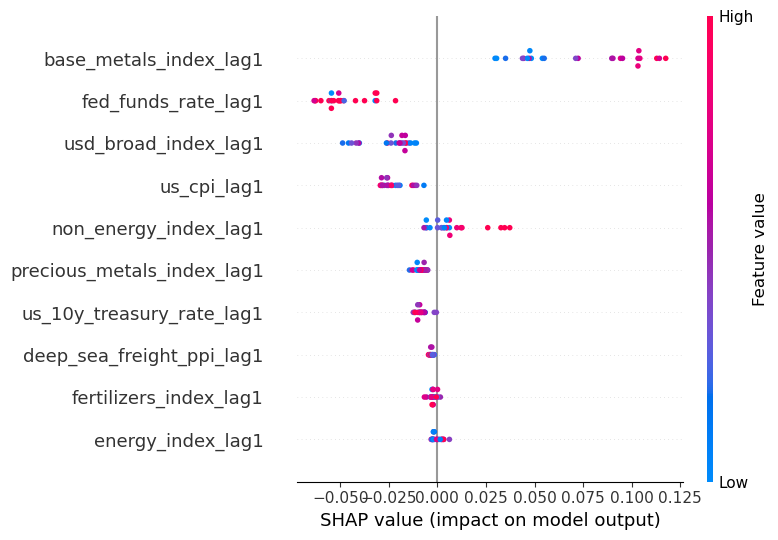

In [278]:
country = "Saudi_Arabia"

mask = seasonal_model_df.loc[
    X_shap.index, "country_name"
].eq(country)

X_country = X_shap.loc[mask]
country_shap = explainer(X_country)

external_cols = [c for c in X_country.columns if c.endswith("_lag1")]
external_idx = [X_country.columns.get_loc(c) for c in external_cols]

shap.summary_plot(
    country_shap.values[:, external_idx],
    X_country[external_cols],
    max_display=10
)

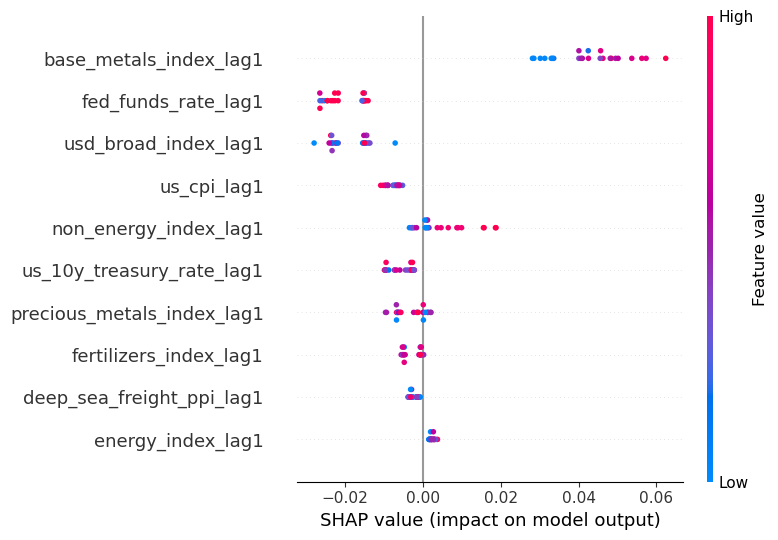

In [279]:
country = "China"

mask = seasonal_model_df.loc[
    X_shap.index, "country_name"
].eq(country)

X_country = X_shap.loc[mask]
country_shap = explainer(X_country)

external_cols = [c for c in X_country.columns if c.endswith("_lag1")]
external_idx = [X_country.columns.get_loc(c) for c in external_cols]

shap.summary_plot(
    country_shap.values[:, external_idx],
    X_country[external_cols],
    max_display=10
)

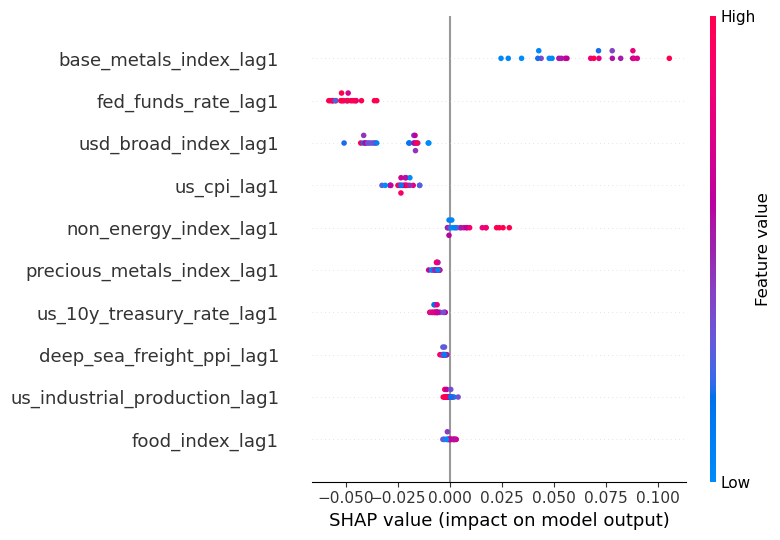

In [280]:
country = "Australia"

mask = seasonal_model_df.loc[
    X_shap.index, "country_name"
].eq(country)

X_country = X_shap.loc[mask]
country_shap = explainer(X_country)

external_cols = [c for c in X_country.columns if c.endswith("_lag1")]
external_idx = [X_country.columns.get_loc(c) for c in external_cols]

shap.summary_plot(
    country_shap.values[:, external_idx],
    X_country[external_cols],
    max_display=10
)

In [281]:
tree_predictions = np.array([
    tree.predict(X_shap)
    for tree in rf_seasonal.estimators_
])

lower_95 = np.percentile(tree_predictions, 2.5, axis=0)
upper_95 = np.percentile(tree_predictions, 97.5, axis=0)

print(lower_95.shape, upper_95.shape)

(432,) (432,)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/va

In [282]:
X_interval = X_shap.to_numpy()

tree_predictions = np.array([
    tree.predict(X_interval)
    for tree in rf_seasonal.estimators_
])

lower_95 = np.percentile(tree_predictions, 2.5, axis=0)
upper_95 = np.percentile(tree_predictions, 97.5, axis=0)

print(lower_95.shape, upper_95.shape)

(432,) (432,)


In [283]:
interval_results = seasonal_model_df.loc[
    X_shap.index,
    ["date", "country_name", "flowCode", "primaryValue"]
].copy()

interval_results["Prediction"] = np.expm1(
    rf_seasonal.predict(X_shap)
)
interval_results["Lower"] = np.expm1(lower_95)
interval_results["Upper"] = np.expm1(upper_95)

interval_results["Covered"] = (
    interval_results["primaryValue"]
    .between(interval_results["Lower"], interval_results["Upper"])
)

print(
    "Observed coverage:",
    round(interval_results["Covered"].mean() * 100, 2),
    "%"
)

Observed coverage: 94.44 %


In [284]:
interval_results["Width"] = (
    interval_results["Upper"] - interval_results["Lower"]
)

country_interval_summary = (
    interval_results.groupby("country_name")
    .agg(
        Observations=("Covered", "size"),
        Coverage=("Covered", "mean"),
        Mean_Width=("Width", "mean")
    )
    .reset_index()
)

country_interval_summary["Coverage"] *= 100
country_interval_summary["Mean_Width"] /= 1e9

display(
    country_interval_summary
    .sort_values("Coverage")
    .round(2)
)

,country_name,Observations,Coverage,Mean_Width
4,China,24,83.33,51.41
7,India,24,83.33,16.88
17,United_States,24,87.50,52.18
12,Republic_of_Korea,24,87.50,18.32
11,Mexico,24,87.50,17.72
16,United_Kingdom,24,91.67,18.57
0,Argentina,24,91.67,3.73
6,Germany,24,91.67,40.57
2,Brazil,24,95.83,12.24
5,France,24,100.00,18.91


In [285]:
interval_results["Relative_Width"] = (
    interval_results["Width"] / interval_results["Prediction"]
) * 100

relative_width_summary = (
    interval_results.groupby("country_name")
    .agg(
        Coverage=("Covered", "mean"),
        Median_Relative_Width=("Relative_Width", "median")
    )
    .reset_index()
)

relative_width_summary["Coverage"] *= 100

display(
    relative_width_summary
    .sort_values("Median_Relative_Width")
    .round(2)
)

,country_name,Coverage,Median_Relative_Width
4,China,83.33,22.50
10,Japan,100.00,26.60
17,United_States,87.50,27.54
5,France,100.00,28.29
6,Germany,91.67,28.30
9,Italy,100.00,28.56
7,India,83.33,33.02
16,United_Kingdom,91.67,34.39
11,Mexico,87.50,35.91
12,Republic_of_Korea,87.50,36.16


In [287]:
feature = "base_metals_index_lag1"

X_train_removed = X_train_seasonal.drop(columns=[feature])
X_test_removed = X_test_seasonal.drop(columns=[feature])

rf_removed = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_removed.fit(X_train_removed, y_train_seasonal)

removed_pred = np.expm1(
    rf_removed.predict(X_test_removed)
)

removed_mape = (
    np.abs((seasonal_actual - removed_pred) / seasonal_actual).mean()
    * 100
)


In [288]:
print("Original MAPE:", round(seasonal_mape, 3))
print("MAPE without base metals:", round(removed_mape, 3))
print("MAPE change:", round(removed_mape - seasonal_mape, 3))

Original MAPE: 6.659
MAPE without base metals: 6.859
MAPE change: 0.2


In [289]:
feature = "fed_funds_rate_lag1"

model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)

model.fit(
    X_train_seasonal.drop(columns=feature),
    y_train_seasonal
)

pred = np.expm1(
    model.predict(X_test_seasonal.drop(columns=feature))
)

mape = np.mean(abs((seasonal_actual - pred) / seasonal_actual)) * 100

print("MAPE without Fed rate:", round(mape, 3))
print("MAPE change:", round(mape - seasonal_mape, 3))

MAPE without Fed rate: 6.734
MAPE change: 0.076


In [290]:
feature = "usd_broad_index_lag1"

model.fit(
    X_train_seasonal.drop(columns=feature),
    y_train_seasonal
)

pred = np.expm1(
    model.predict(X_test_seasonal.drop(columns=feature))
)

mape = np.mean(abs((seasonal_actual - pred) / seasonal_actual)) * 100

print("MAPE without US dollar index:", round(mape, 3))
print("MAPE change:", round(mape - seasonal_mape, 3))

MAPE without US dollar index: 6.81
MAPE change: 0.151


In [291]:
feature = "us_cpi_lag1"

model.fit(
    X_train_seasonal.drop(columns=feature),
    y_train_seasonal
)

pred = np.expm1(
    model.predict(X_test_seasonal.drop(columns=feature))
)

mape = np.mean(abs((seasonal_actual - pred) / seasonal_actual)) * 100

print("MAPE without US CPI:", round(mape, 3))
print("MAPE change:", round(mape - seasonal_mape, 3))

MAPE without US CPI: 6.592
MAPE change: -0.067


In [292]:
feature = "non_energy_index_lag1"

model.fit(
    X_train_seasonal.drop(columns=feature),
    y_train_seasonal
)

pred = np.expm1(
    model.predict(X_test_seasonal.drop(columns=feature))
)

mape = np.mean(abs((seasonal_actual - pred) / seasonal_actual)) * 100

print("MAPE without non-energy index:", round(mape, 3))
print("MAPE change:", round(mape - seasonal_mape, 3))

MAPE without non-energy index: 6.723
MAPE change: 0.064


In [293]:
feature = "crude_oil_avg_usd_lag1"

model.fit(X_train_seasonal.drop(columns=feature), y_train_seasonal)

pred = np.expm1(
    model.predict(X_test_seasonal.drop(columns=feature))
)

mape = np.mean(abs((seasonal_actual - pred) / seasonal_actual)) * 100

print("MAPE without crude oil:", round(mape, 3))
print("MAPE change:", round(mape - seasonal_mape, 3))

MAPE without crude oil: 6.666
MAPE change: 0.008


In [294]:
mask = seasonal_model_df.loc[X_shap.index, "country_name"].eq("Saudi_Arabia")

X_saudi = X_shap.loc[mask].copy()
baseline = np.expm1(rf_seasonal.predict(X_saudi))

X_saudi["crude_oil_avg_usd_lag1"] *= 1.20
scenario = np.expm1(rf_seasonal.predict(X_saudi))

print("Average prediction change:",
      round(((scenario - baseline) / baseline).mean() * 100, 2), "%")

Average prediction change: 0.4 %


In [295]:
mask = seasonal_model_df.loc[X_shap.index, "country_name"].eq("Australia")

X_aus = X_shap.loc[mask].copy()
baseline = np.expm1(rf_seasonal.predict(X_aus))

X_aus["base_metals_index_lag1"] *= 0.85
scenario = np.expm1(rf_seasonal.predict(X_aus))

print("Average prediction change:",
      round(((scenario - baseline) / baseline).mean() * 100, 2), "%")

Average prediction change: -1.99 %


In [296]:
X_rate = X_shap.copy()
baseline = np.expm1(rf_seasonal.predict(X_rate))

X_rate["fed_funds_rate_lag1"] += 1
scenario = np.expm1(rf_seasonal.predict(X_rate))

print("Average prediction change:",
      round(((scenario - baseline) / baseline).mean() * 100, 2), "%")

Average prediction change: 0.0 %


In [297]:
change = ((scenario - baseline) / baseline) * 100

print("Mean:", round(change.mean(), 4), "%")
print("Median:", round(np.median(change), 4), "%")
print("Range:", round(change.min(), 4), "to", round(change.max(), 4), "%")

Mean: 0.0036 %
Median: 0.0 %
Range: -0.6828 to 0.4168 %


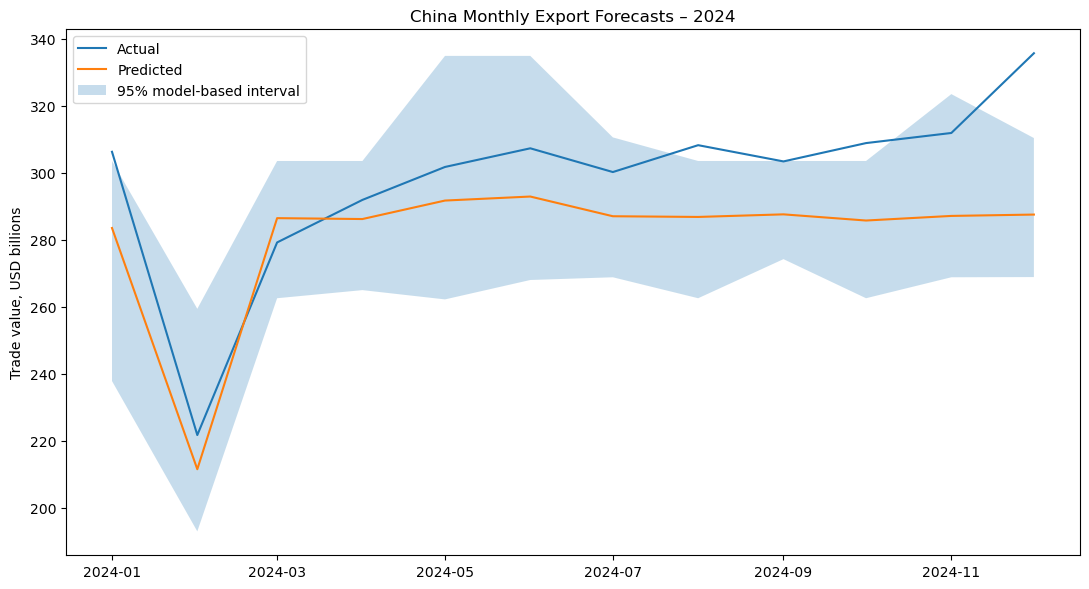

In [298]:
plot_df = interval_results[
    (interval_results["country_name"] == "China") &
    (interval_results["flowCode"] == "X")
].sort_values("date")

plt.figure(figsize=(11, 6))
plt.plot(plot_df["date"], plot_df["primaryValue"] / 1e9, label="Actual")
plt.plot(plot_df["date"], plot_df["Prediction"] / 1e9, label="Predicted")
plt.fill_between(
    plot_df["date"],
    plot_df["Lower"] / 1e9,
    plot_df["Upper"] / 1e9,
    alpha=0.25,
    label="95% model-based interval"
)

plt.title("China Monthly Export Forecasts – 2024")
plt.ylabel("Trade value, USD billions")
plt.legend()
plt.tight_layout()
plt.show()

In [299]:
plt.savefig(
    "china_export_forecast_2024.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [300]:
from sklearn.base import clone
from sklearn.metrics import mean_absolute_percentage_error

model_1 = clone(rf_seasonal)
model_2 = clone(rf_seasonal)

model_1.fit(X_train_seasonal, y_train_seasonal)
model_2.fit(X_train_seasonal, y_train_seasonal)

pred_1 = np.expm1(model_1.predict(X_test_seasonal))
pred_2 = np.expm1(model_2.predict(X_test_seasonal))

mape_1 = mean_absolute_percentage_error(seasonal_actual, pred_1) * 100
mape_2 = mean_absolute_percentage_error(seasonal_actual, pred_2) * 100

print("Run 1 MAPE:", round(mape_1, 6))
print("Run 2 MAPE:", round(mape_2, 6))
print("MAPE difference:", round(abs(mape_1 - mape_2), 6))
print("Maximum prediction difference:", np.max(abs(pred_1 - pred_2)))

Run 1 MAPE: 6.659495
Run 2 MAPE: 6.659495
MAPE difference: 0.0
Maximum prediction difference: 0.0030517578125
